<a href="https://colab.research.google.com/github/shreyajain2397/food101/blob/main/food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np # linear algebra
import pandas as pd


In [4]:
! pip install torch torchvision numpy pandas matplotlib scikit-learn opendatasets

In [5]:
import opendatasets as od
import pandas

od.download(
    "https://www.kaggle.com/datasets/anishhhhhhhh18/food-101-20-class")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: 
Your Kaggle username: shreyajain97
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/anishhhhhhhh18/food-101-20-class


100%|██████████| 941M/941M [00:11<00:00, 85.6MB/s]


In [6]:
import torch
from torchvision import datasets, transforms
import torchvision
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score

In [6]:
torch.manual_seed(42)

In [7]:
# ================================
# 1. Imports
# ================================
import os
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# ================================
# 2. Device
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================
# 3. Transforms (WITH AUGMENTATION)
# ================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

Using device: cpu


In [8]:

import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


# ================================
# 5. Load Dataset
# ================================
data_path = "/content/food-101-20-class"  # adjust if needed


train_dir = f"{data_path}/train_data"
val_dir   = f"{data_path}/validation_data"
test_dir  = f"{data_path}/test_data"


train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = ImageFolder(
    val_dir,
    transform=test_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)


classes = train_dataset.classes
print("Total classes:", len(classes))

Total classes: 20


In [9]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [10]:
images, labels = next(iter(train_loader))

print(labels.min())
print(labels.max())

tensor(1)
tensor(16)


In [11]:
try:
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    print("Loaded pretrained weights")
except:
    print("No internet → using random initialization")
    model = efficientnet_b0(weights=None)

# Replace classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
model = model.to(device)

# ================================
# 8. Loss + Optimizer + Scheduler
# ================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.9MB/s]


Loaded pretrained weights


In [12]:
import torch
import numpy as np

# Early stopping params
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0

# Save path
best_model_path = "best_model.pth"

# Scheduler (Reduce LR when val loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2
)

In [ ]:
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

num_epochs = 10

for epoch in range(num_epochs):

    # ===================== TRAIN =====================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = correct / total
    train_loss /= len(train_loader)

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    val_loss /= len(test_loader)

    # ===================== STORE =====================
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # ===================== SCHEDULER =====================
    scheduler.step(val_loss)

    # ===================== SAVE BEST MODEL =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), best_model_path)
        print("✅ Best model saved!")

    else:
        epochs_no_improve += 1

    # ===================== EARLY STOPPING =====================
    if epochs_no_improve >= patience:
        print("⛔ Early stopping triggered!")
        break

Epoch [1/10] Train Loss: 1.8852, Val Loss: 1.1264 | Train Acc: 0.5477, Val Acc: 0.8156
✅ Best model saved!
Epoch [2/10] Train Loss: 1.3719, Val Loss: 1.0334 | Train Acc: 0.7213, Val Acc: 0.8580
✅ Best model saved!
Epoch [3/10] Train Loss: 1.2730, Val Loss: 0.9891 | Train Acc: 0.7569, Val Acc: 0.8680
✅ Best model saved!
Epoch [4/10] Train Loss: 1.2083, Val Loss: 0.9726 | Train Acc: 0.7845, Val Acc: 0.8684
✅ Best model saved!
Epoch [5/10] Train Loss: 1.1619, Val Loss: 0.9455 | Train Acc: 0.8017, Val Acc: 0.8832
✅ Best model saved!
Epoch [6/10] Train Loss: 1.1234, Val Loss: 0.9416 | Train Acc: 0.8169, Val Acc: 0.8828
✅ Best model saved!
Epoch [7/10] Train Loss: 1.0850, Val Loss: 0.9186 | Train Acc: 0.8336, Val Acc: 0.8876
✅ Best model saved!
Epoch [8/10] Train Loss: 1.0701, Val Loss: 0.9164 | Train Acc: 0.8359, Val Acc: 0.8992
✅ Best model saved!
Epoch [9/10] Train Loss: 1.0559, Val Loss: 0.9102 | Train Acc: 0.8449, Val Acc: 0.8992
✅ Best model saved!
Epoch [10/10] Train Loss: 1.0298, Val

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

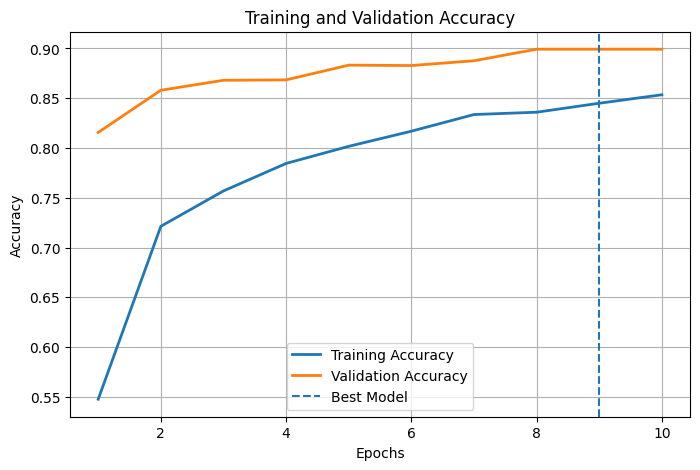

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc_history, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc_history, label="Validation Accuracy", linewidth=2)

# Mark best epoch (lowest val loss)
best_epoch = val_loss_history.index(min(val_loss_history)) + 1
plt.axvline(x=best_epoch, linestyle='--', label='Best Model')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# ================================
# 10. Evaluation
# ================================
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 89.92%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.92%


In [ ]:
class_names = train_dataset.classes

print(class_names)

['apple_pie', 'cannoli', 'chicken_curry', 'chocolate_cake', 'cup_cakes', 'donuts', 'dumplings', 'french_fries', 'fried_rice', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'ice_cream', 'nachos', 'omelette', 'pizza', 'ramen', 'samosa', 'spring_rolls', 'waffles']


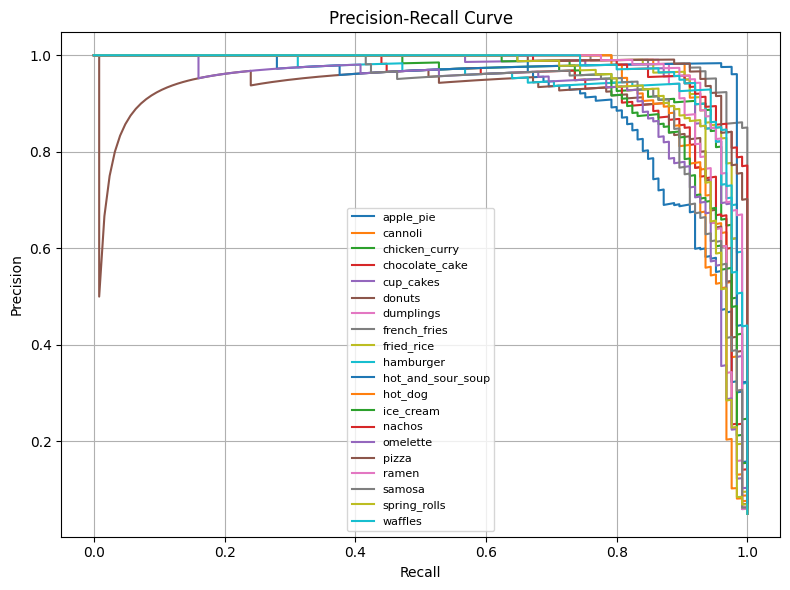

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Ensure probabilities are stacked correctly
y_probs = np.vstack(all_probs)

# Number of classes
n_classes = len(set(all_labels))

# Binarize labels
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

# Use selected class names


plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]   # ← REPLACED HERE
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="best", fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

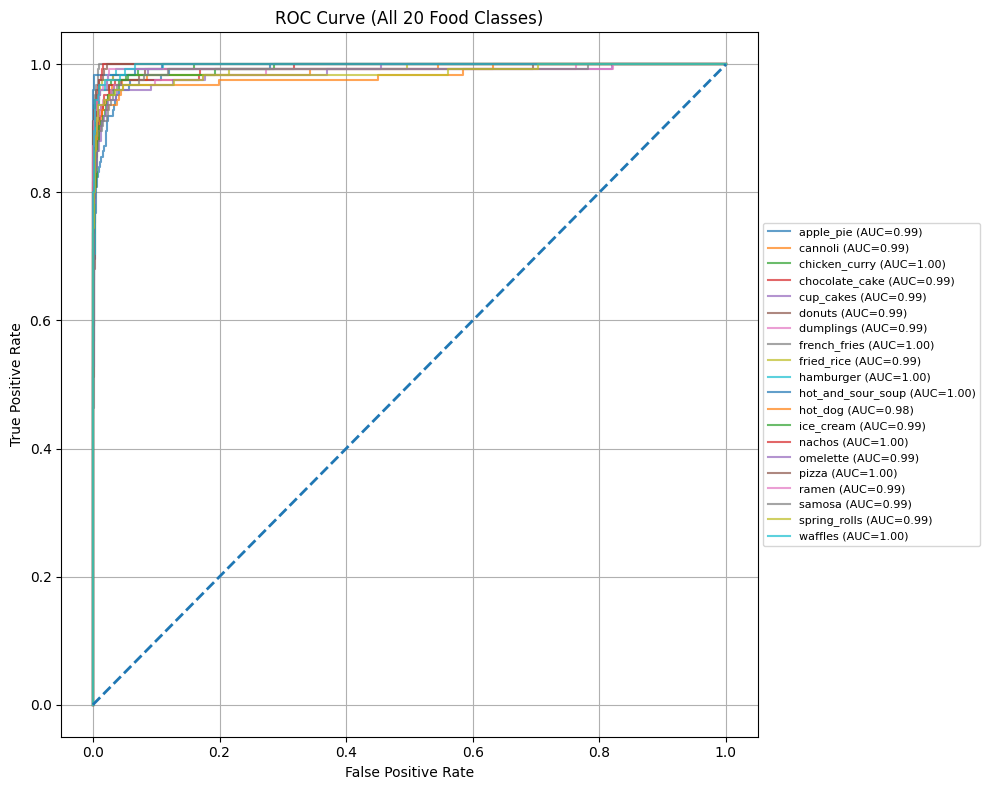

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure correct shape
y_probs = np.vstack(all_probs)

# Class names


plt.figure(figsize=(10,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=1.5,
        alpha=0.7,   # helps reduce clutter
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All 20 Food Classes)")

# Move legend outside for clarity
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "efficientnet_food101.pth")
print("Model saved!")

Model saved!


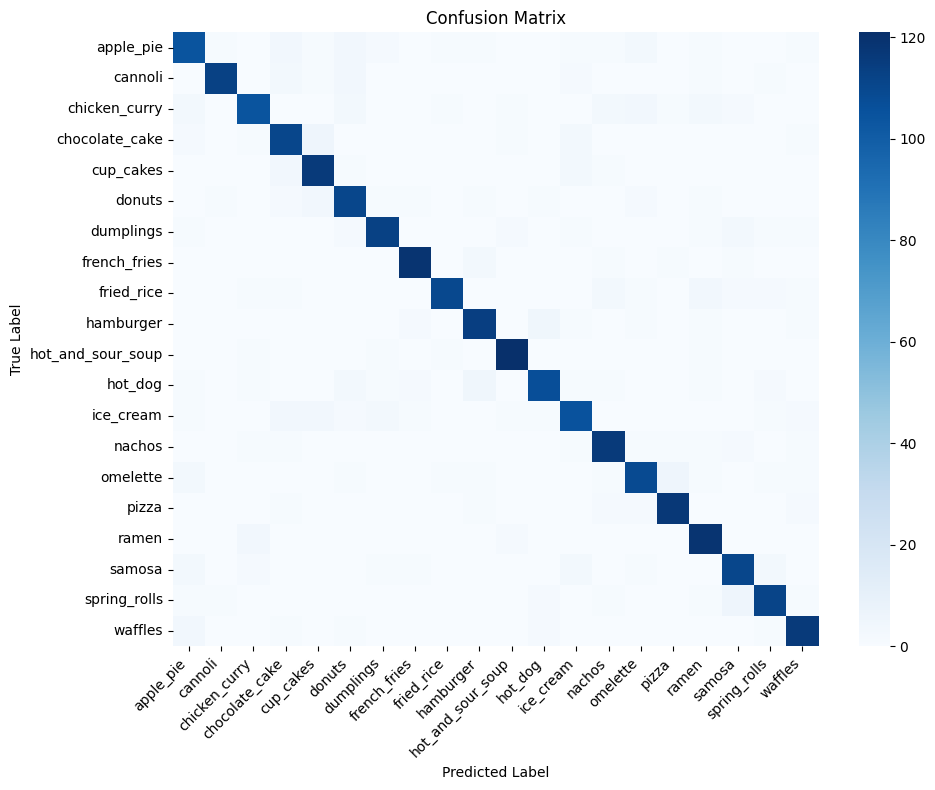

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names (only your selected 20 classes)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 20)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
import os
# Enables the Device-Side Assertions
os.environ['TORCH_USE_CUDA_DSA'] = '1'
# Optional: Force synchronous execution to get the exact line causing the error
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import torch


In [ ]:
EPOCHS = 10

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10
Train Accuracy: 0.5833
Validation Accuracy: 0.7768

Epoch 2/10
Train Accuracy: 0.6894
Validation Accuracy: 0.8000

Epoch 3/10
Train Accuracy: 0.7252
Validation Accuracy: 0.8120

Epoch 4/10
Train Accuracy: 0.7338
Validation Accuracy: 0.8136

Epoch 5/10
Train Accuracy: 0.7502
Validation Accuracy: 0.8300

Epoch 6/10
Train Accuracy: 0.7685
Validation Accuracy: 0.8240

Epoch 7/10
Train Accuracy: 0.7736
Validation Accuracy: 0.8192

Epoch 8/10
Train Accuracy: 0.7862
Validation Accuracy: 0.8484

Epoch 9/10
Train Accuracy: 0.7966
Validation Accuracy: 0.8292

Epoch 10/10
Train Accuracy: 0.7997
Validation Accuracy: 0.8412


In [ ]:
model.load_state_dict(torch.load("best_model_resnet.pth"))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'best_model_resnet.pth'

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 84.96%


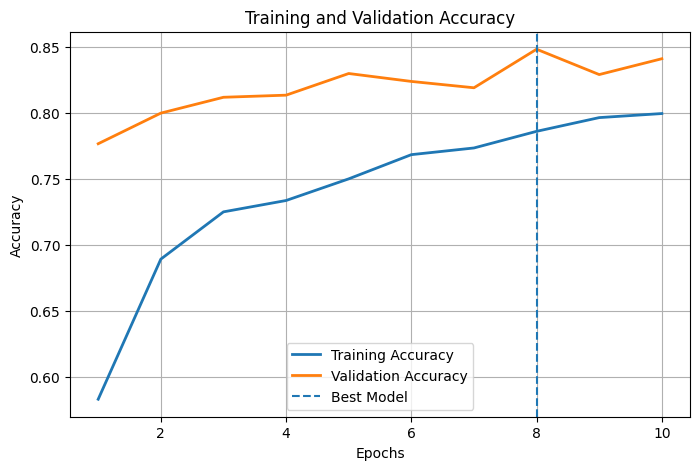

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc_history, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc_history, label="Validation Accuracy", linewidth=2)

# Mark best epoch (lowest val loss)
best_epoch = val_loss_history.index(min(val_loss_history)) + 1
plt.axvline(x=best_epoch, linestyle='--', label='Best Model')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

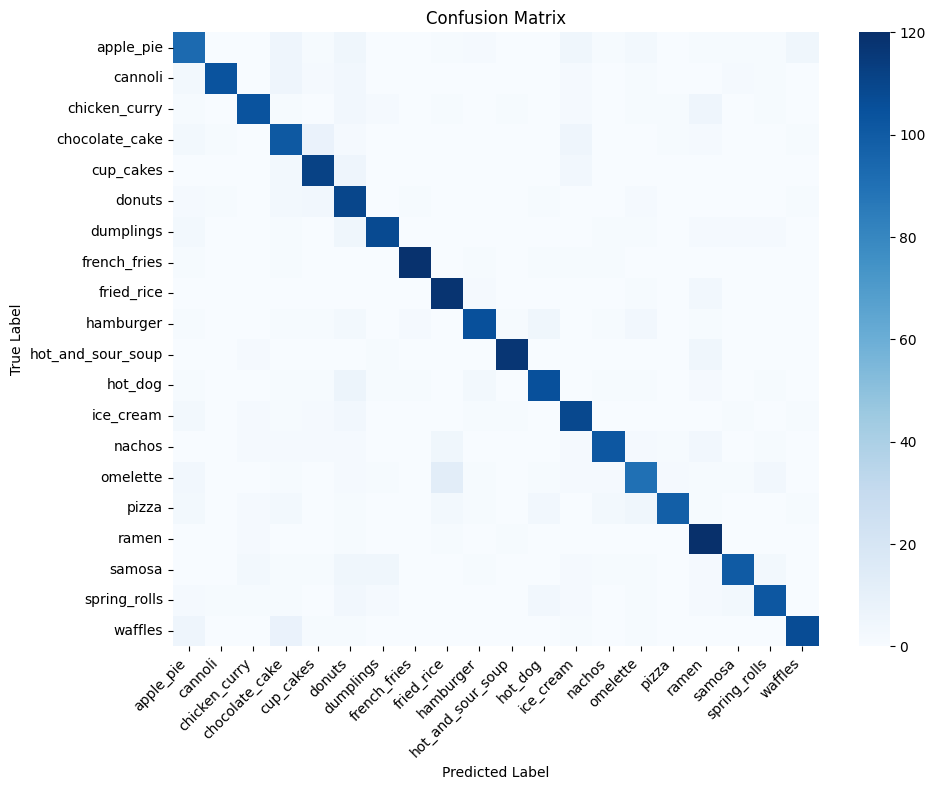

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names (only your selected 20 classes)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

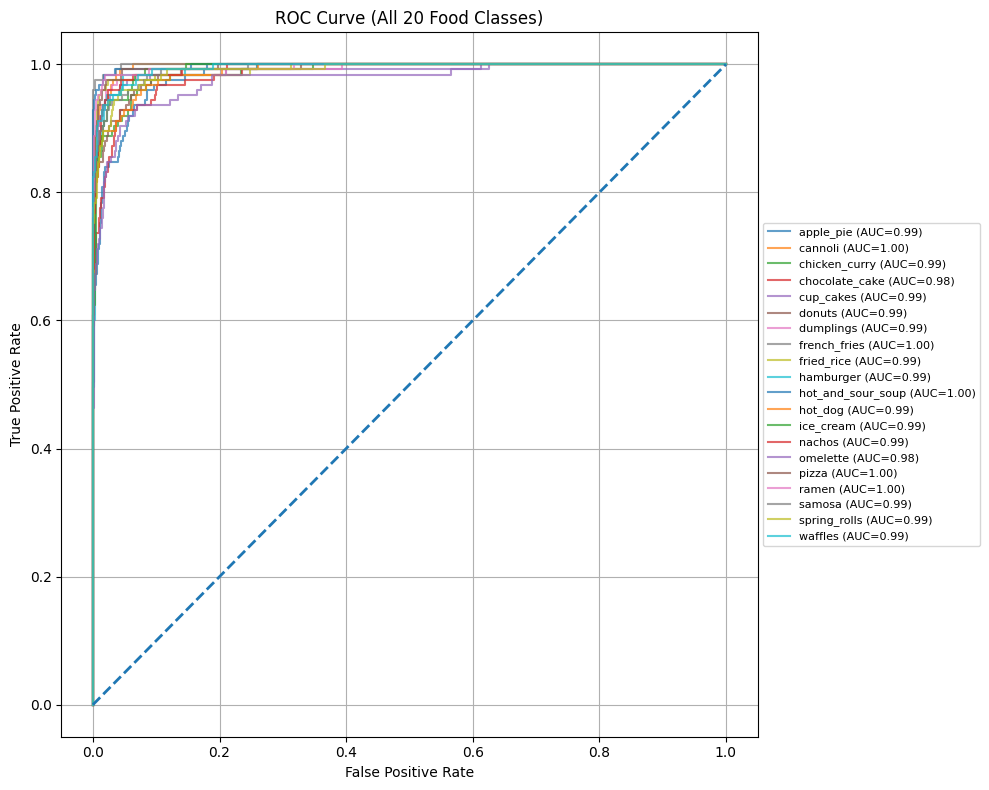

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure correct shape
y_probs = np.vstack(all_probs)

# Class names


plt.figure(figsize=(10,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=1.5,
        alpha=0.7,   # helps reduce clutter
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All 20 Food Classes)")

# Move legend outside for clarity
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)

plt.grid(True)
plt.tight_layout()
plt.show()

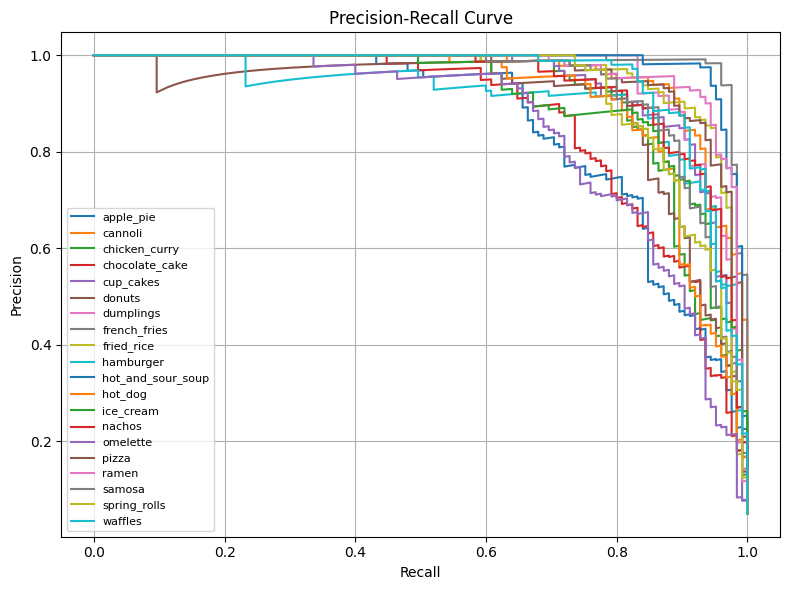

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Ensure probabilities are stacked correctly
y_probs = np.vstack(all_probs)

# Number of classes
n_classes = len(set(all_labels))

# Binarize labels
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

# Use selected class names


plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]   # ← REPLACED HERE
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="best", fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

mobilnet


In [13]:
from torchvision import models

model = models.mobilenet_v2(pretrained=True)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    20
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 135MB/s]


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [15]:
EPOCHS = 10

train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10
Train Accuracy: 0.5688
Validation Accuracy: 0.7640

Epoch 2/10
Train Accuracy: 0.6797
Validation Accuracy: 0.8124

Epoch 3/10
Train Accuracy: 0.7131
Validation Accuracy: 0.8280

Epoch 4/10
Train Accuracy: 0.7465
Validation Accuracy: 0.8316

Epoch 5/10
Train Accuracy: 0.7557
Validation Accuracy: 0.8352

Epoch 6/10
Train Accuracy: 0.7673
Validation Accuracy: 0.8324

Epoch 7/10
Train Accuracy: 0.7784
Validation Accuracy: 0.8456

Epoch 8/10
Train Accuracy: 0.7794
Validation Accuracy: 0.8424

Epoch 9/10
Train Accuracy: 0.7977
Validation Accuracy: 0.8424

Epoch 10/10
Train Accuracy: 0.8018
Validation Accuracy: 0.8540


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 86.76%


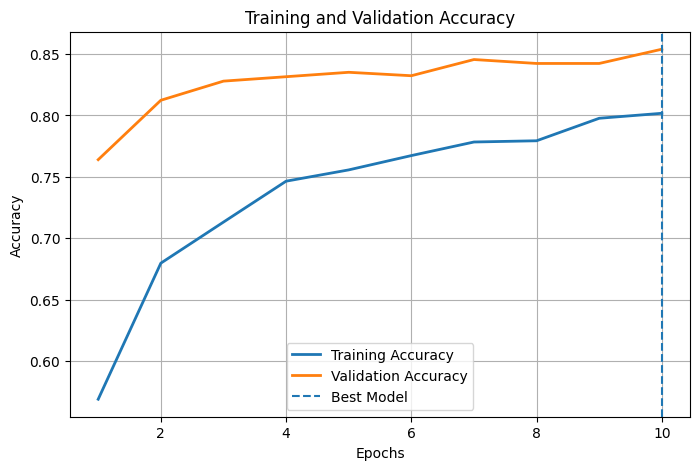

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc_history, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc_history, label="Validation Accuracy", linewidth=2)

# Mark best epoch (lowest val loss)
best_epoch = val_loss_history.index(min(val_loss_history)) + 1
plt.axvline(x=best_epoch, linestyle='--', label='Best Model')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [19]:
class_names=train_dataset.classes

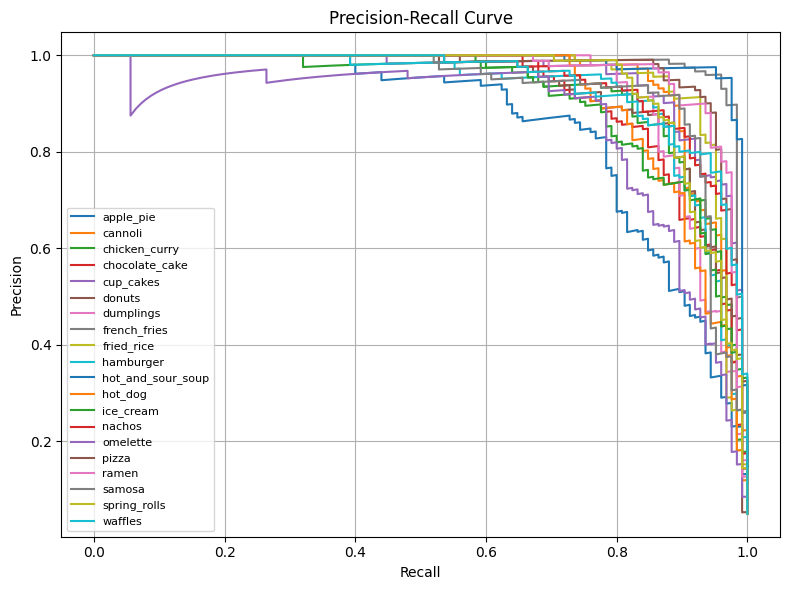

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# Ensure probabilities are stacked correctly
y_probs = np.vstack(all_probs)

# Number of classes
n_classes = len(set(all_labels))

# Binarize labels
y_true_bin = label_binarize(all_labels, classes=list(range(n_classes)))

# Use selected class names


plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]   # ← REPLACED HERE
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="best", fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()

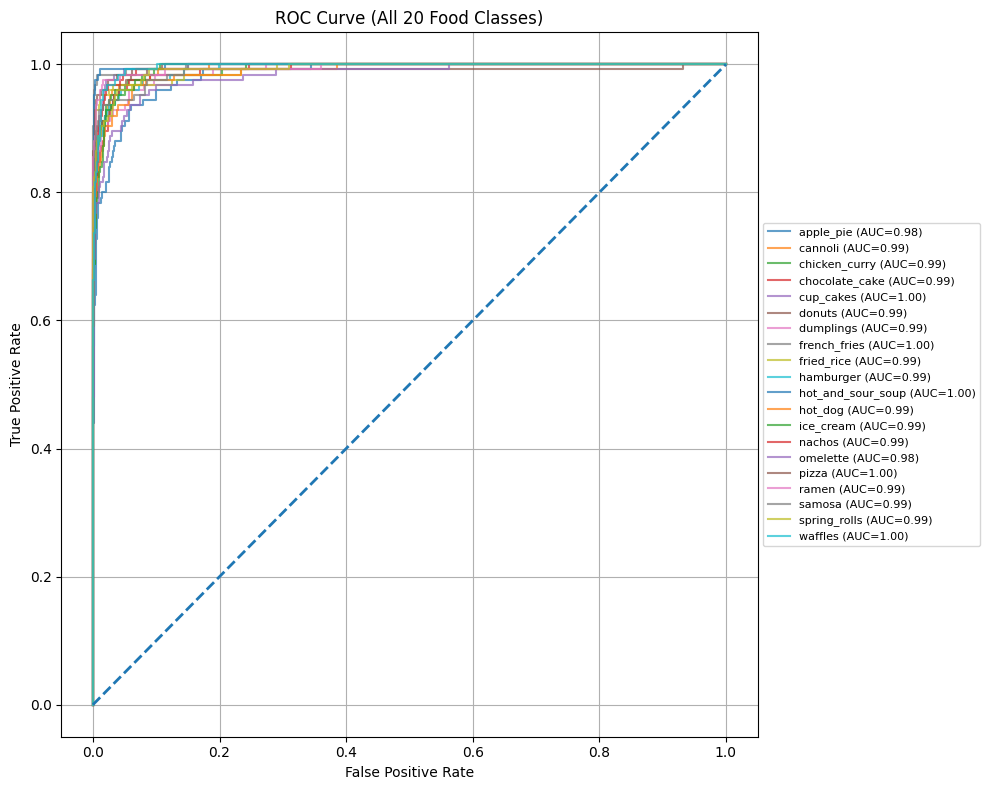

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Ensure correct shape
y_probs = np.vstack(all_probs)

# Class names


plt.figure(figsize=(10,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=1.5,
        alpha=0.7,   # helps reduce clutter
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2)

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All 20 Food Classes)")

# Move legend outside for clarity
plt.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)

plt.grid(True)
plt.tight_layout()
plt.show()

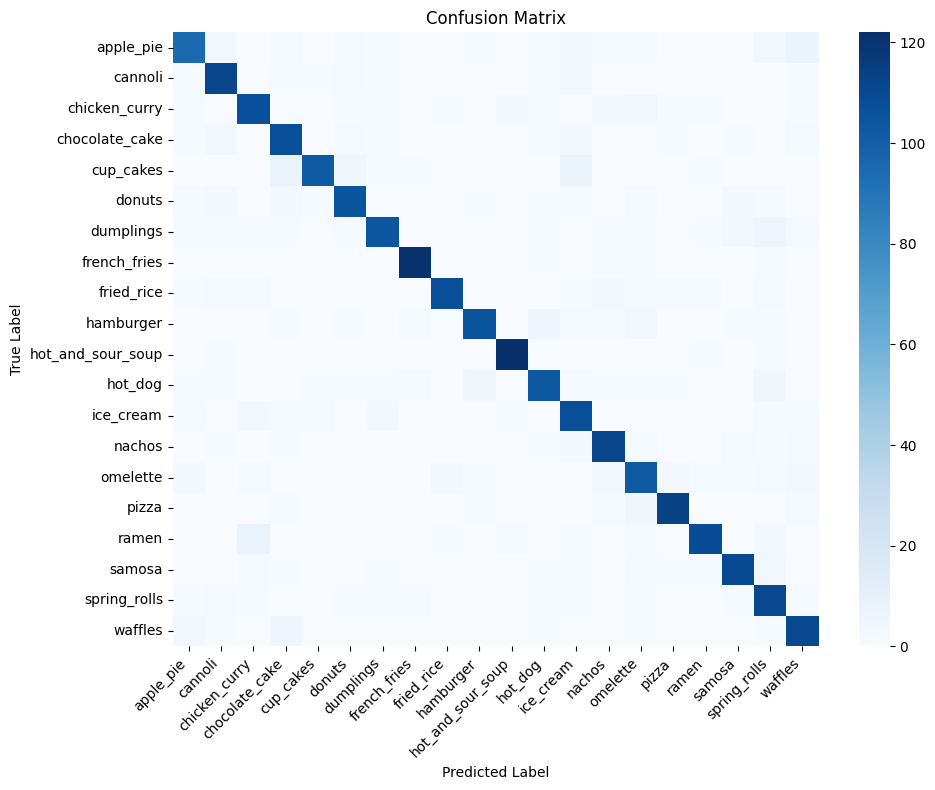

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names (only your selected 20 classes)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=False,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

vit

In [23]:
import timm
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load pretrained ViT
vit_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True
)

# Remove classifier head
vit_model.head = nn.Identity()

vit_model = vit_model.to(device)

vit_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [24]:
import numpy as np

vit_features = []
vit_labels = []

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        feats = vit_model(images)

        vit_features.append(
            feats.cpu().numpy()
        )

        vit_labels.extend(
            labels.numpy()
        )

# Final feature matrix
X_vit = np.vstack(vit_features)

y_vit = np.array(vit_labels)

print(X_vit.shape)

(15000, 768)


In [25]:
EPOCHS = 10
model=vit_model
train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10
Train Accuracy: 0.0000
Validation Accuracy: 0.0000


KeyboardInterrupt: 

rf

In [ ]:
from torchvision import models

efficientnet = model
# Remove classifier
feature_extractor = nn.Sequential(
    *list(efficientnet.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
images, labels = next(iter(train_loader))

print(labels)
print("Min:", labels.min().item())
print("Max:", labels.max().item())

tensor([19,  1, 11,  1, 10, 16, 16,  9, 18,  2,  6, 11,  6, 18,  1,  4])
Min: 1
Max: 19


In [ ]:
import numpy as np

features = []
labels = []

with torch.no_grad():

    for images, lbls in train_loader:

        images = images.to(device)

        feats = feature_extractor(images)

        feats = feats.view(feats.size(0), -1)

        features.append(feats.cpu().numpy())

        labels.extend(lbls.numpy())

X = np.vstack(features)
y = np.array(labels)

print(X.shape)

(15000, 2048)


In [ ]:
print(class_names)

['apple_pie', 'cannoli', 'chicken_curry', 'chocolate_cake', 'cup_cakes', 'donuts', 'dumplings', 'french_fries', 'fried_rice', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'ice_cream', 'nachos', 'omelette', 'pizza', 'ramen', 'samosa', 'spring_rolls', 'waffles']


In [ ]:
high_gi_classes = [
    'apple_pie',
    'cannoli',
    'chocolate_cake',
    'cup_cakes',
    'donuts',
    'french_fries',
    'fried_rice',
    'hamburger',
    'hot_dog',
    'nachos',
    'pizza',
    'waffles',
    'samosa'
]

binary_labels = []

for lbl in y:

    class_name = class_names[lbl]

    if class_name in high_gi_classes:
        binary_labels.append(1)   # High GI
    else:
        binary_labels.append(0)   # Low GI

binary_labels = np.array(binary_labels)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    binary_labels,
    test_size=0.25,
    random_state=42,
    stratify=binary_labels
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_probs = rf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_probs)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.9761514928677931


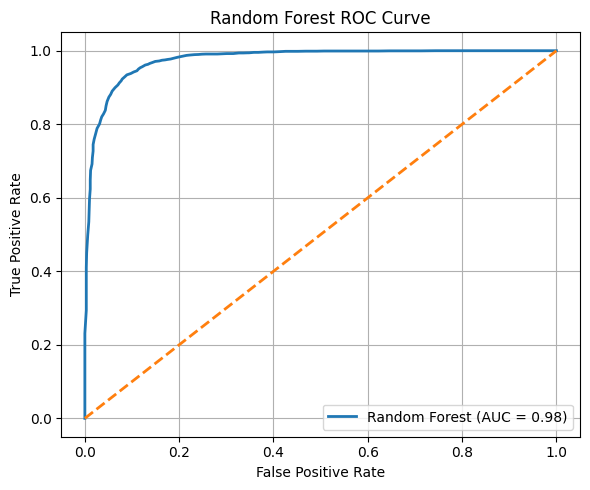

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_score:.2f})"
)

# Diagonal reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2
)

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

# KMeans clustering
kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

In [ ]:
sil_score = silhouette_score(X, cluster_labels)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.17804481


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

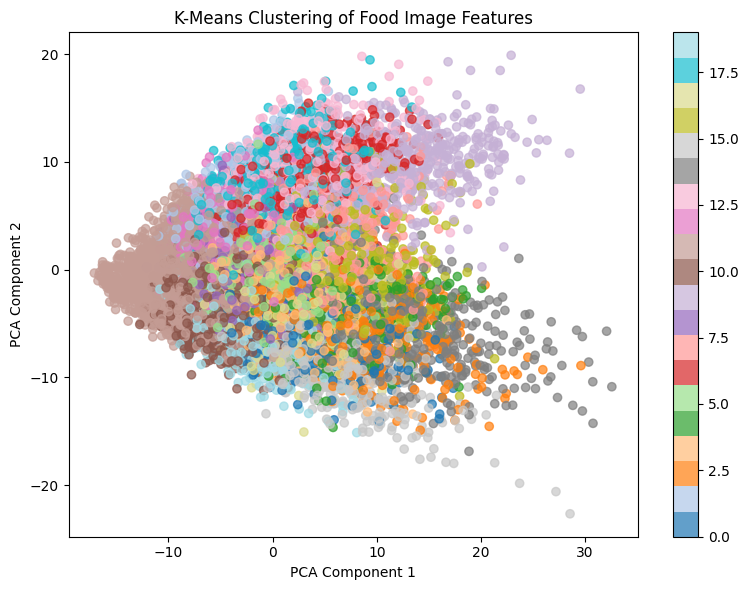

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='tab20',
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("K-Means Clustering of Food Image Features")

plt.colorbar(scatter)

plt.tight_layout()
plt.show()

In [ ]:
food_names = [class_names[label] for label in y]

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Cluster": cluster_labels,
    "Food": food_names
})

dominant_food = df.groupby("Cluster")["Food"] \
                  .agg(lambda x: x.value_counts().index[0])

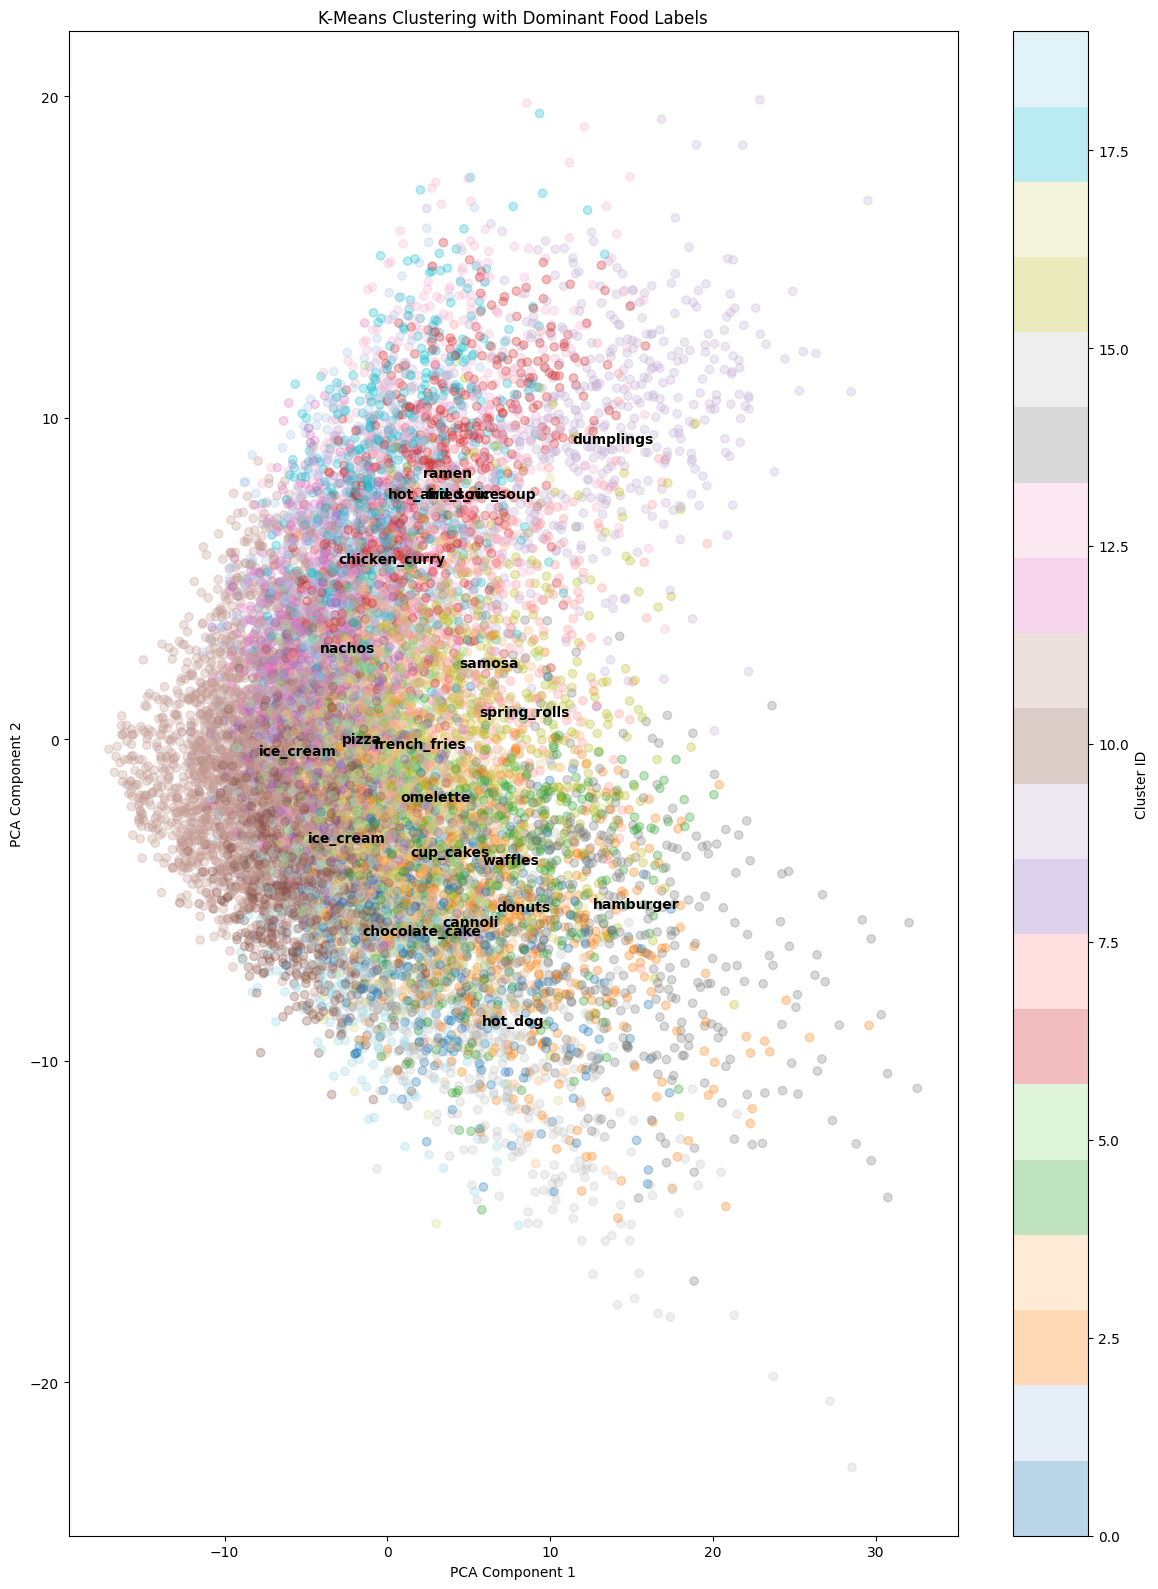

In [ ]:
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12,16))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='tab20',
    alpha=0.3
)

# Label cluster centers
for i, food in dominant_food.items():

    plt.text(
        centers_pca[i,0],
        centers_pca[i,1],
        food,
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("K-Means Clustering with Dominant Food Labels")

plt.colorbar(scatter, label="Cluster ID")

plt.tight_layout()
plt.show()

In [34]:
import torch
import torch.nn as nn

from torchvision import transforms, models
from PIL import Image

import matplotlib.pyplot as plt

In [35]:
model = models.efficientnet_b0(pretrained=False)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    20
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [36]:
model.load_state_dict(
    torch.load(
        "/content/efficientnet_food101 (2).pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [37]:
train_dataset.classes

['apple_pie',
 'cannoli',
 'chicken_curry',
 'chocolate_cake',
 'cup_cakes',
 'donuts',
 'dumplings',
 'french_fries',
 'fried_rice',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'ice_cream',
 'nachos',
 'omelette',
 'pizza',
 'ramen',
 'samosa',
 'spring_rolls',
 'waffles']

In [38]:
model = models.efficientnet_b0(pretrained=False)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    20
)

In [40]:
class_names=train_dataset.classes

In [41]:
class_names

['apple_pie',
 'cannoli',
 'chicken_curry',
 'chocolate_cake',
 'cup_cakes',
 'donuts',
 'dumplings',
 'french_fries',
 'fried_rice',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'ice_cream',
 'nachos',
 'omelette',
 'pizza',
 'ramen',
 'samosa',
 'spring_rolls',
 'waffles']

In [42]:
model = models.efficientnet_b0(pretrained=False)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    20
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [61]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [65]:


image_path = "/content/food-101-20-class/test_data/apple_pie/101251.jpg"

image = Image.open(image_path).convert("RGB")

In [66]:
input_tensor = transform(image)

input_tensor = input_tensor.unsqueeze(0)

input_tensor = input_tensor.to(device)

In [67]:
with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, predicted = torch.max(
        probabilities,
        1
    )

predicted_class = class_names[
    predicted.item()
]

print("Predicted Food:", predicted_class)

print("Confidence:",
      confidence.item())

Predicted Food: cannoli
Confidence: 0.06580302119255066


In [56]:
import pandas as pd

usda_df = pd.read_excel("/content/usda_dataset.xlsx")
usda_df=usda_df.iloc[1:]

print(usda_df.head())

  Food code   Main food description WWEIA Category number  \
1  11100000               Milk, NFS                  1004   
2  11111000             Milk, whole                  1002   
3  11112110  Milk, reduced fat (2%)                  1004   
4  11112210      Milk, low fat (1%)                  1006   
5  11113000   Milk, fat free (skim)                  1008   

  WWEIA Category description Energy (kcal) Protein (g) Carbohydrate (g)  \
1          Milk, reduced fat            52        3.33             4.83   
2                Milk, whole            61        3.27             4.63   
3          Milk, reduced fat            50        3.36              4.9   
4               Milk, lowfat            43        3.38             5.18   
5               Milk, nonfat            34        3.43             4.92   

  Sugars, total\n(g) Fiber, total dietary (g) Total Fat (g)  ... 20:1\n(g)  \
1               4.88                        0          2.14  ...     0.002   
2               4.81      

In [12]:
nutrition_features = [
    'Energy (kcal)',
    'Protein (g)',
    'Carbohydrate (g)',
    'Sugars, total\n(g)',
    'Fiber, total dietary (g)',
    'Total Fat (g)',
    'Fatty acids, total saturated (g)',
    'Cholesterol (mg)',
    'Sodium (mg)',
    'Vitamin C (mg)',
    'Calcium (mg)',
    'Iron\n(mg)',
    'Potassium (mg)'
]

In [13]:
predicted_food = "pizza"

In [14]:
nutrition_df = usda_df[
    ['Main food description'] + nutrition_features
]

nutrition_df = nutrition_df.dropna()

print(nutrition_df.shape)

(5431, 14)


In [15]:
matched_foods = usda_df[
    usda_df['Main food description']
    .str.contains(predicted_food, case=False, na=False)
]

print(matched_foods[['Main food description']].head())

                      Main food description
404               Topping from cheese pizza
405            Topping from vegetable pizza
406                 Topping from meat pizza
407   Topping from meat and vegetable pizza
2625                          Dessert pizza


In [16]:
food_info = matched_foods.iloc[0]

nutrition = {
    "Calories": food_info['Energy (kcal)'],
    "Protein": food_info['Protein (g)'],
    "Carbohydrates": food_info['Carbohydrate (g)'],
    "Sugar": food_info['Sugars, total\n(g)'],
    "Fiber": food_info['Fiber, total dietary (g)'],
    "Fat": food_info['Total Fat (g)'],
    "Sodium": food_info['Sodium (mg)'],
    "Potassium": food_info['Potassium (mg)']
}

print(nutrition)

{'Calories': 230, 'Protein': 16.86, 'Carbohydrates': 7.62, 'Sugar': 4.38, 'Fiber': 1, 'Fat': 14.67, 'Sodium': 713, 'Potassium': 261}


In [17]:
nutrition_df = pd.DataFrame(
    nutrition.items(),
    columns=['Nutrient','Value']
)

print(nutrition_df)

        Nutrient   Value
0       Calories  230.00
1        Protein   16.86
2  Carbohydrates    7.62
3          Sugar    4.38
4          Fiber    1.00
5            Fat   14.67
6         Sodium  713.00
7      Potassium  261.00


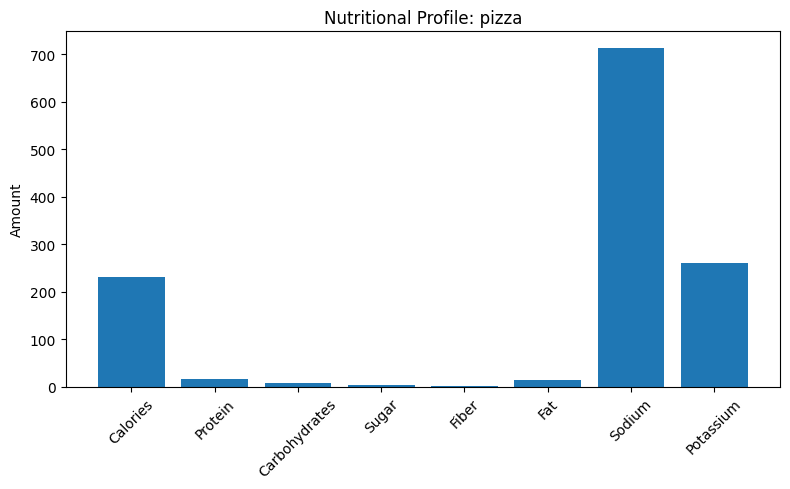

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    nutrition_df['Nutrient'],
    nutrition_df['Value']
)

plt.xticks(rotation=45)

plt.ylabel("Amount")

plt.title(f"Nutritional Profile: {predicted_food}")

plt.tight_layout()
plt.show()

In [36]:
X = nutrition_df[nutrition_features].values

food_names = nutrition_df['Main food description'].values

In [37]:
food_names

array(['Milk, NFS', 'Milk, whole', 'Milk, reduced fat (2%)', ...,
       'Vegetables as ingredient in stews',
       'Sauce as ingredient in hamburgers',
       'Industrial oil as ingredient in food'], dtype=object)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [67]:
food_classes = [

    'apple pie',
    'baby back ribs',
    'baklava',
    'beef carpaccio',
    'beef tartare',
    'beet salad',
    'beignets',
    'bibimbap',
    'bread pudding',
    'breakfast burrito',
    'bruschetta',
    'caesar salad',
    'cannoli',
    'caprese salad',
    'carrot cake',
    'ceviche',
    'cheese plate',
    'cheesecake',
    'chicken curry',
    'chicken quesadilla',
    'chicken wings',
    'chocolate cake',
    'chocolate mousse',
    'churros',
    'clam chowder',
    'club sandwich',
    'crab cakes',
    'creme brulee',
    'croque madame',
    'cup cakes',
    'deviled eggs',
    'donuts',
    'dumplings',
    'edamame',
    'eggs benedict',
    'escargots',
    'falafel',
    'filet mignon',
    'fish and chips',
    'foie gras',
    'french fries',
    'french onion soup',
    'french toast',
    'fried calamari',
    'fried rice',
    'frozen yogurt',
    'garlic bread',
    'gnocchi',
    'greek salad',
    'grilled cheese sandwich',
    'grilled salmon',
    'guacamole',
    'gyoza',
    'hamburger',
    'hot and sour soup',
    'hot dog',
    'huevos rancheros',
    'hummus',
    'ice cream',
    'lasagna',
    'lobster bisque',
    'lobster roll sandwich',
    'macaroni and cheese',
    'macarons',
    'miso soup',
    'mussels',
    'nachos',
    'omelette',
    'onion rings',
    'oysters',
    'pad thai',
    'paella',
    'pancakes',
    'panna cotta',
    'peking duck',
    'pho',
    'pizza',
    'pork chop',
    'poutine',
    'prime rib',
    'pulled pork sandwich',
    'ramen',
    'ravioli',
    'red velvet cake',
    'risotto',
    'samosa',
    'sashimi',
    'scallops',
    'seaweed salad',
    'shrimp and grits',
    'spaghetti bolognese',
    'spaghetti carbonara',
    'spring rolls',
    'steak',
    'strawberry shortcake',
    'sushi',
    'tacos',
    'takoyaki',
    'tiramisu',
    'tuna tartare',
    'waffles'
]

In [68]:
usda_df=pd.read_excel("/content/usda_dataset.xlsx")
usda_df=usda_df.iloc[1:]

print(usda_df.head())

  Food code   Main food description WWEIA Category number  \
1  11100000               Milk, NFS                  1004   
2  11111000             Milk, whole                  1002   
3  11112110  Milk, reduced fat (2%)                  1004   
4  11112210      Milk, low fat (1%)                  1006   
5  11113000   Milk, fat free (skim)                  1008   

  WWEIA Category description Energy (kcal) Protein (g) Carbohydrate (g)  \
1          Milk, reduced fat            52        3.33             4.83   
2                Milk, whole            61        3.27             4.63   
3          Milk, reduced fat            50        3.36              4.9   
4               Milk, lowfat            43        3.38             5.18   
5               Milk, nonfat            34        3.43             4.92   

  Sugars, total\n(g) Fiber, total dietary (g) Total Fat (g)  ... 20:1\n(g)  \
1               4.88                        0          2.14  ...     0.002   
2               4.81      

In [69]:
nutrition_data = []

for food in food_classes:

    # Match USDA foods
    matched_foods = usda_df[
        usda_df['Main food description']
        .str.contains(food.replace('_', ' '),
                      case=False,
                      na=False)
    ]

    # Skip if no match
    if len(matched_foods) == 0:
        continue

    # Take first match
    food_info = matched_foods.iloc[0]

    nutrition_data.append({

        "Food": food,

        "Calories":
            food_info['Energy (kcal)'],

        "Protein":
            food_info['Protein (g)'],

        "Carbohydrates":
            food_info['Carbohydrate (g)'],

        "Sugar":
            food_info['Sugars, total\n(g)'],

        "Fiber":
            food_info['Fiber, total dietary (g)'],

        "Fat":
            food_info['Total Fat (g)'],

        "Sodium":
            food_info['Sodium (mg)'],

        "Potassium":
            food_info['Potassium (mg)']
    })

In [70]:
nutrition_data

[{'Food': 'apple pie',
  'Calories': 100,
  'Protein': 0.1,
  'Carbohydrates': 26.1,
  'Sugar': 13.8,
  'Fiber': 1,
  'Fat': 0.1,
  'Sodium': 47,
  'Potassium': 45},
 {'Food': 'baklava',
  'Calories': 440,
  'Protein': 6.58,
  'Carbohydrates': 37.55,
  'Sugar': 12.8,
  'Fiber': 2.5,
  'Fat': 29.34,
  'Sodium': 311,
  'Potassium': 170},
 {'Food': 'bibimbap',
  'Calories': 76,
  'Protein': 5.5,
  'Carbohydrates': 8.11,
  'Sugar': 1.52,
  'Fiber': 1.1,
  'Fat': 2.44,
  'Sodium': 435,
  'Potassium': 244},
 {'Food': 'bruschetta',
  'Calories': 171,
  'Protein': 4.29,
  'Carbohydrates': 21.32,
  'Sugar': 3.34,
  'Fiber': 1.5,
  'Fat': 7.61,
  'Sodium': 264,
  'Potassium': 187},
 {'Food': 'caesar salad',
  'Calories': 77,
  'Protein': 4,
  'Carbohydrates': 7.49,
  'Sugar': 1.23,
  'Fiber': 1.8,
  'Fat': 3.41,
  'Sodium': 238,
  'Potassium': 250},
 {'Food': 'ceviche',
  'Calories': 63,
  'Protein': 10.53,
  'Carbohydrates': 3.58,
  'Sugar': 1.34,
  'Fiber': 0.5,
  'Fat': 0.76,
  'Sodium': 149,

In [71]:
nutrition_df = pd.DataFrame(nutrition_data)

print(nutrition_df)

                       Food  Calories  Protein  Carbohydrates  Sugar  Fiber  \
0                 apple pie       100     0.10          26.10  13.80    1.0   
1                   baklava       440     6.58          37.55  12.80    2.5   
2                  bibimbap        76     5.50           8.11   1.52    1.1   
3                bruschetta       171     4.29          21.32   3.34    1.5   
4              caesar salad        77     4.00           7.49   1.23    1.8   
5                   ceviche        63    10.53           3.58   1.34    0.5   
6                cheesecake       399     5.29          34.82  26.64    0.5   
7             chicken curry       107     6.48           6.54   2.56    1.4   
8                   churros       419     6.05          48.87  23.38    2.6   
9              clam chowder        35     2.48           5.26   1.22    0.8   
10            club sandwich       222    15.08          23.09   2.62    1.0   
11             creme brulee       113     4.06      

In [72]:
feature_cols = [
    'Calories',
    'Protein',
    'Carbohydrates',
    'Sugar',
    'Fiber',
    'Fat',
    'Sodium',
    'Potassium'
]

X = nutrition_df[feature_cols].values

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [28]:
nutrition_df['Cluster'] = cluster_labels

print(nutrition_df)

             Food  Calories  Protein  Carbohydrates  Sugar  Fiber    Fat  \
0       apple_pie       100     0.10          26.10  13.80    1.0   0.10   
1   chicken_curry       107     6.48           6.54   2.56    1.4   6.48   
2       dumplings       144    15.69           8.04   0.45    0.3   5.55   
3    french_fries       225     2.50          23.23   0.34    1.8  14.07   
4       hamburger       285    15.27          29.18   4.24    1.0  11.35   
5         hot_dog       310    11.70           2.89   1.26    0.0  28.00   
6       ice_cream       221     3.57          26.36  22.86    0.8  11.30   
7          nachos       265     7.60          23.85   0.39    1.7  15.85   
8           pizza       230    16.86           7.62   4.38    1.0  14.67   
9           ramen        66     1.53           9.04   0.30    0.4   2.64   
10         samosa       310     5.14          33.16   1.28    1.8  17.47   

    Sodium  Potassium  Cluster  
0       47         45        3  
1      376        280

In [29]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.1586744355708604


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

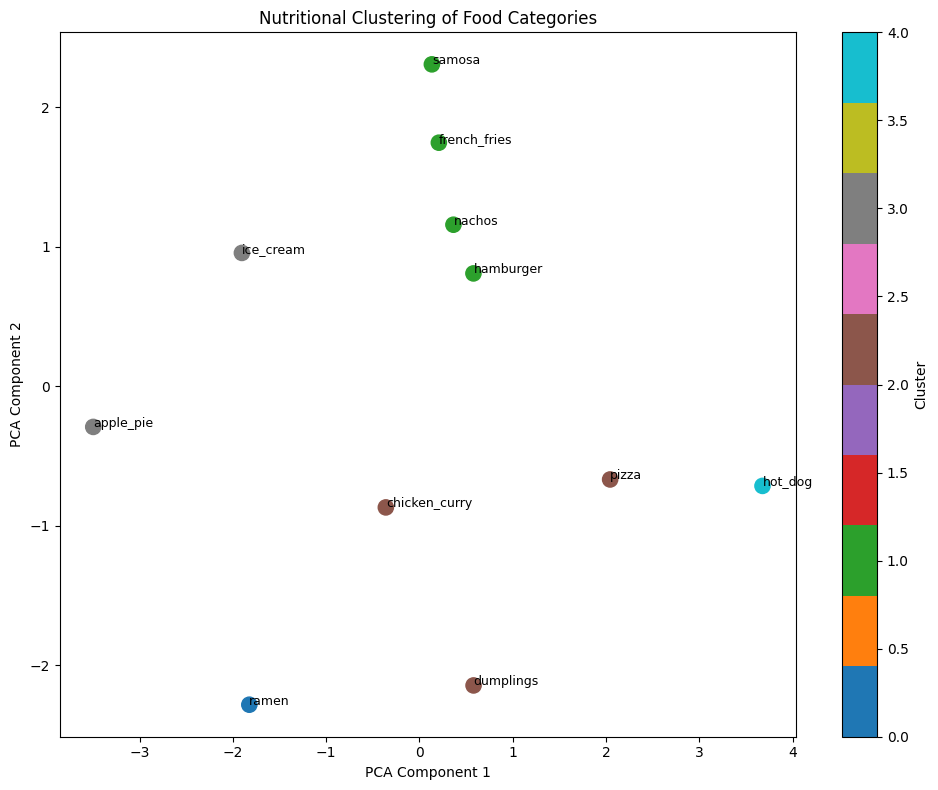

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='tab10',
    s=120
)

# Add food labels
for i, food in enumerate(nutrition_df['Food']):

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        food,
        fontsize=9
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Nutritional Clustering of Food Categories")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

In [68]:
feature_cols = [
    'Calories',
    'Protein',
    'Carbohydrates',
    'Sugar',
    'Fiber',
    'Fat',
    'Sodium',
    'Potassium'
]

X = nutrition_df[feature_cols]

In [69]:
y = nutrition_df['Cluster']

In [71]:
y

,Cluster
0,3
1,2
2,2
3,1
4,1
5,4
6,3
7,1
8,2
9,0


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,

)

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
y_pred = rf.predict(X_test)

In [87]:
y_pred

array([2, 3], dtype=int32)

In [88]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.5


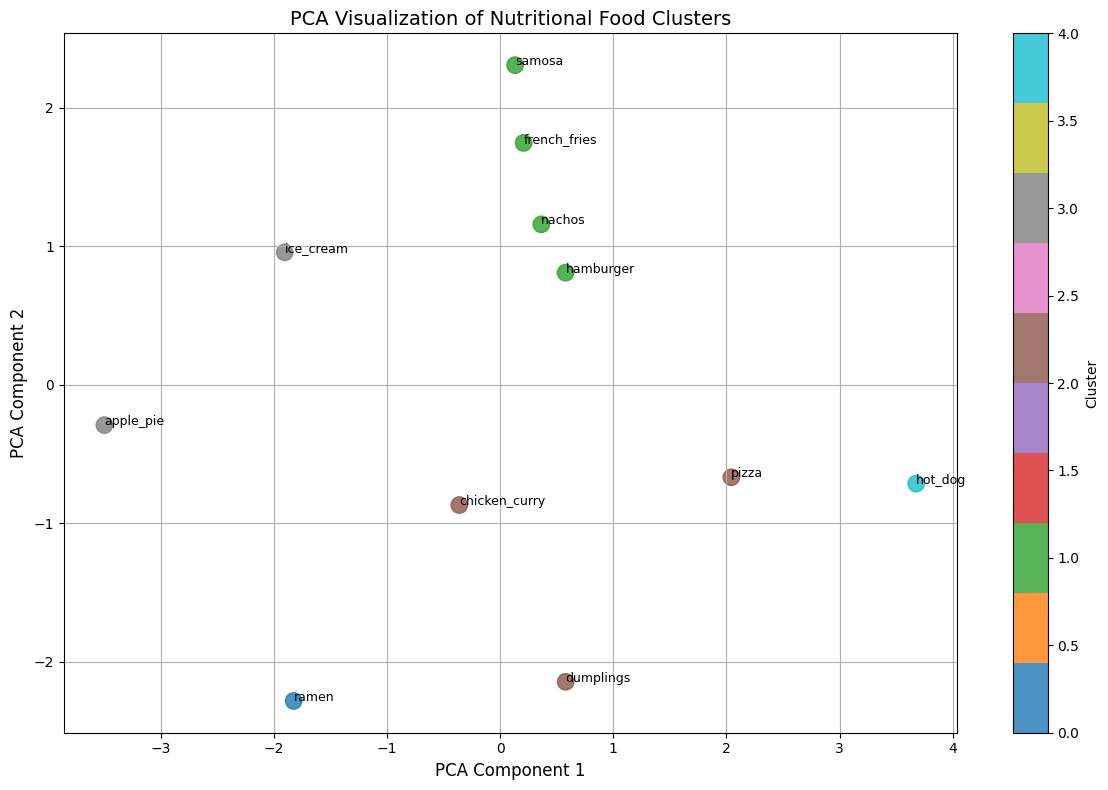

In [89]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='tab10',
    s=140,
    alpha=0.8
)

# Add food labels
for i, food in enumerate(
    nutrition_df['Food']
):

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        food,
        fontsize=9
    )

plt.xlabel(
    "PCA Component 1",
    fontsize=12
)

plt.ylabel(
    "PCA Component 2",
    fontsize=12
)

plt.title(
    "PCA Visualization of Nutritional Food Clusters",
    fontsize=14
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [90]:
from sklearn.metrics.pairwise import cosine_similarity

In [91]:
feature_cols = [
    'Calories',
    'Protein',
    'Carbohydrates',
    'Sugar',
    'Fiber',
    'Fat',
    'Sodium',
    'Potassium'
]

X = nutrition_df[feature_cols].values

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [93]:
similarity_matrix = cosine_similarity(
    X_scaled
)

In [94]:
def recommend_foods(food_name, top_n=5):

    # Find index
    idx = nutrition_df[
        nutrition_df['Food'] == food_name
    ].index[0]

    # Similarity scores
    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    # Sort descending
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove itself
    similarity_scores = similarity_scores[1:]

    # Top recommendations
    top_recommendations = similarity_scores[:top_n]

    print(f"\nRecommended foods for: {food_name}\n")

    for i, score in top_recommendations:

        recommended_food = nutrition_df.iloc[i]['Food']

        print(
            f"{recommended_food}"
            f"  (Similarity: {score:.2f})"
        )

In [97]:
nutrition_df['PCOS_Health_Score'] = (

    # Positive nutrients
    nutrition_df['Protein'] * 2 +

    nutrition_df['Fiber'] * 3 +

    nutrition_df['Potassium'] * 0.01

    # Negative nutrients
    - nutrition_df['Sugar'] * 3

    - nutrition_df['Carbohydrates'] * 1.5

    - nutrition_df['Fat'] * 2

    - nutrition_df['Sodium'] * 0.01
)

In [98]:
def pcos_recommendations(food_name, top_n=5):

    # Get target food index
    idx = nutrition_df[
        nutrition_df['Food'] == food_name
    ].index[0]

    target = nutrition_df.iloc[idx]

    target_score = target[
        'PCOS_Health_Score'
    ]

    # Similarity scores
    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    # Sort descending
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, sim in similarity_scores:

        if i == idx:
            continue

        candidate = nutrition_df.iloc[i]

        candidate_score = candidate[
            'PCOS_Health_Score'
        ]

        # Recommend ONLY healthier foods
        if candidate_score > target_score:

            recommendations.append({

                "Food":
                    candidate['Food'],

                "Similarity":
                    round(sim,2),

                "PCOS_Health_Score":
                    round(candidate_score,2),

                "Protein":
                    candidate['Protein'],

                "Fiber":
                    candidate['Fiber'],

                "Sugar":
                    candidate['Sugar']
            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

In [99]:
pcos_recommendations("pizza")

,Food,Similarity,PCOS_Health_Score,Protein,Fiber,Sugar
0,dumplings,0.50,4.65,15.69,0.3,0.45
1,chicken_curry,0.05,-14.25,6.48,1.4,2.56
2,ramen,-0.43,-18.03,1.53,0.4,0.30


In [96]:
recommend_foods("apple_pie")


Recommended foods for: apple_pie

ice_cream  (Similarity: 0.63)
ramen  (Similarity: 0.61)
chicken_curry  (Similarity: 0.11)
samosa  (Similarity: -0.13)
dumplings  (Similarity: -0.17)


In [100]:
def calculate_pcos_score(row):

    score = 0

    # -----------------------------
    # Positive Factors
    # -----------------------------

    # High protein
    score += row['Protein'] * 2

    # High fiber
    score += row['Fiber'] * 3

    # Potassium beneficial
    score += row['Potassium'] * 0.01

    # -----------------------------
    # Negative Factors
    # -----------------------------

    # High sugar harmful
    score -= row['Sugar'] * 3

    # Excess carbs
    score -= row['Carbohydrates'] * 1.5

    # High fat
    score -= row['Fat'] * 2

    # High sodium
    score -= row['Sodium'] * 0.01

    return score

In [101]:
nutrition_df['PCOS_Score'] = nutrition_df.apply(
    calculate_pcos_score,
    axis=1
)

In [102]:
def classify_food(score):

    if score >= 40:
        return "Highly Recommended"

    elif score >= 20:
        return "Moderately Recommended"

    else:
        return "Avoid / Limit"

In [103]:
nutrition_df['PCOS_Category'] = (
    nutrition_df['PCOS_Score']
    .apply(classify_food)
)

In [104]:
from sklearn.metrics.pairwise import cosine_similarity

# Similarity matrix
similarity_matrix = cosine_similarity(X_scaled)

In [107]:
def pcos_food_recommendation(food_name, top_n=10):

    idx = nutrition_df[
        nutrition_df['Food'] == food_name
    ].index[0]

    target = nutrition_df.iloc[idx]

    target_score = target['PCOS_Score']

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, sim in similarity_scores:

        if i == idx:
            continue

        candidate = nutrition_df.iloc[i]

        # -----------------------------
        # Recommend ONLY healthier foods
        # -----------------------------

        if candidate['PCOS_Score'] > target_score:

            recommendations.append({

                "Food":
                    candidate['Food'],

                "Similarity":
                    round(sim,2),

                "PCOS_Score":
                    round(candidate['PCOS_Score'],2),

                "Category":
                    candidate['PCOS_Category'],

                "Protein":
                    candidate['Protein'],

                "Fiber":
                    candidate['Fiber'],

                "Sugar":
                    candidate['Sugar']
            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

In [108]:
pcos_food_recommendation("pizza")

,Food,Similarity,PCOS_Score,Category,Protein,Fiber,Sugar
0,dumplings,0.50,4.65,Avoid / Limit,15.69,0.3,0.45
1,chicken_curry,0.05,-14.25,Avoid / Limit,6.48,1.4,2.56
2,ramen,-0.43,-18.03,Avoid / Limit,1.53,0.4,0.30


In [109]:
import pandas as pd

gi_df = pd.read_excel(
    "/content/gi_values.xlsx"
)

print(gi_df.head())

                food_types                          food gi_values
0  High-carbohydrate foods            White wheat bread*    75 ± 2
1                      NaN  Whole wheat/whole meal bread    74 ± 2
2                      NaN         Specialty grain bread    53 ± 2
3                      NaN        Unleavened wheat bread    70 ± 5
4                      NaN                    Wheat roti    62 ± 3


In [114]:
# Convert both columns to lowercase
nutrition_df['food'] = (
    nutrition_df['Food']
    .str.lower()
    .str.strip()
)

gi_df['food'] = (
    gi_df['food']
    .str.lower()
    .str.strip()
)

# Merge
nutrition_df = nutrition_df.merge(
    gi_df,
    on='food',
    how='left'
)

In [116]:
nutrition_df.columns

Index(['Food', 'Calories', 'Protein', 'Carbohydrates', 'Sugar', 'Fiber', 'Fat',
       'Sodium', 'Potassium', 'Cluster', 'PCOS_Health_Score', 'PCOS_Score',
       'PCOS_Category', 'food', 'food_types', 'gi_values'],
      dtype='object')

In [117]:
nutrition_df['GI'] = (
    nutrition_df['gi_values']
    .fillna(
        nutrition_df['gi_values'].mean()
    )
)

/tmp/ipykernel_2226/2293910545.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(


In [118]:
def calculate_pcos_score(row):

    score = 0

    # -----------------------------
    # Positive Nutrients
    # -----------------------------

    score += row['Protein'] * 2

    score += row['Fiber'] * 3

    score += row['Potassium'] * 0.01

    # -----------------------------
    # Negative Nutrients
    # -----------------------------

    score -= row['Sugar'] * 3

    score -= row['Carbohydrates'] * 1.5

    score -= row['Fat'] * 2

    score -= row['Sodium'] * 0.01

    # -----------------------------
    # GI PENALTY
    # -----------------------------

    score -= row['GI'] * 1.5

    return score

In [119]:
nutrition_df['PCOS_Score'] = (
    nutrition_df.apply(
        calculate_pcos_score,
        axis=1
    )
)

In [120]:
def gi_category(gi):

    if gi < 55:
        return "Low GI"

    elif gi <= 69:
        return "Medium GI"

    else:
        return "High GI"

In [121]:
nutrition_df['GI_Category'] = (
    nutrition_df['GI']
    .apply(gi_category)
)

In [122]:
def pcos_food_recommendation(food_name, top_n=5):

    idx = nutrition_df[
        nutrition_df['Food'] == food_name
    ].index[0]

    target = nutrition_df.iloc[idx]

    target_score = target['PCOS_Score']

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, sim in similarity_scores:

        if i == idx:
            continue

        candidate = nutrition_df.iloc[i]

        # -----------------------------
        # PCOS + GI filtering
        # -----------------------------

        if (
            candidate['PCOS_Score'] > target_score
            and candidate['GI'] < 55
        ):

            recommendations.append({

                "Food":
                    candidate['Food'],

                "Similarity":
                    round(sim,2),

                "GI":
                    candidate['GI'],

                "GI_Category":
                    candidate['GI_Category'],

                "PCOS_Score":
                    round(candidate['PCOS_Score'],2),

                "Protein":
                    candidate['Protein'],

                "Fiber":
                    candidate['Fiber']
            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

""


In [124]:
def calculate_pcos_score(row):

    score = 0

    # -----------------------------
    # Positive nutrients
    # -----------------------------

    score += row['Protein'] * 2

    score += row['Fiber'] * 3

    score += row['Potassium'] * 0.01

    # -----------------------------
    # Negative nutrients
    # -----------------------------

    score -= row['Sugar'] * 3

    score -= row['Carbohydrates'] * 1.5

    score -= row['Fat'] * 2

    score -= row['Sodium'] * 0.01

    # -----------------------------
    # GI Penalty
    # -----------------------------

    # GI improves recommendation
    score -= row['GI'] * 0.8

    return score

In [125]:
def pcos_food_recommendation(food_name, top_n=5):

    idx = nutrition_df[
        nutrition_df['Food'] == food_name
    ].index[0]

    target = nutrition_df.iloc[idx]

    target_score = target['PCOS_Score']

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, sim in similarity_scores:

        if i == idx:
            continue

        candidate = nutrition_df.iloc[i]

        candidate_score = candidate[
            'PCOS_Score'
        ]

        # Recommend healthier foods only
        if candidate_score > target_score:

            # GI-aware ranking bonus
            adjusted_score = (
                candidate_score
                + sim * 10
                - candidate['GI'] * 0.2
            )

            recommendations.append({

                "Food":
                    candidate['Food'],

                "Similarity":
                    round(sim,2),

                "GI":
                    candidate['GI'],

                "PCOS Score":
                    round(adjusted_score,2),

                "Category":
                    classify_food(
                        adjusted_score
                    )
            })

    # Sort by adjusted score
    recommendations = sorted(
        recommendations,
        key=lambda x: x['PCOS Score'],
        reverse=True
    )

    return pd.DataFrame(
        recommendations[:top_n]
    )

In [126]:
pcos_food_recommendation(
    "pizza"
)

""


In [127]:
pip install networkx

In [128]:
import networkx as nx
import matplotlib.pyplot as plt

In [129]:
G = nx.Graph()

In [130]:
for _, row in nutrition_df.iterrows():

    food = row['Food']

    G.add_node(
        food,
        type='food'
    )

In [131]:
for _, row in nutrition_df.iterrows():

    food = row['Food']

    # -----------------------------
    # High Sugar
    # -----------------------------
    if row['Sugar'] > 15:

        G.add_node(
            'High Sugar',
            type='risk'
        )

        G.add_edge(
            food,
            'High Sugar',
            relation='contains'
        )

    # -----------------------------
    # High GI
    # -----------------------------
    if row['GI'] > 70:

        G.add_node(
            'High GI',
            type='risk'
        )

        G.add_edge(
            food,
            'High GI',
            relation='has_GI'
        )

    # -----------------------------
    # High Protein
    # -----------------------------
    if row['Protein'] > 15:

        G.add_node(
            'High Protein',
            type='benefit'
        )

        G.add_edge(
            food,
            'High Protein',
            relation='contains'
        )

In [132]:
G.add_node(
    'PCOS',
    type='disease'
)

G.add_edge(
    'PCOS',
    'Low GI',
    relation='recommended'
)

G.add_edge(
    'PCOS',
    'High Sugar',
    relation='avoid'
)

G.add_edge(
    'PCOS',
    'High GI',
    relation='avoid'
)

G.add_edge(
    'PCOS',
    'High Protein',
    relation='recommended'
)

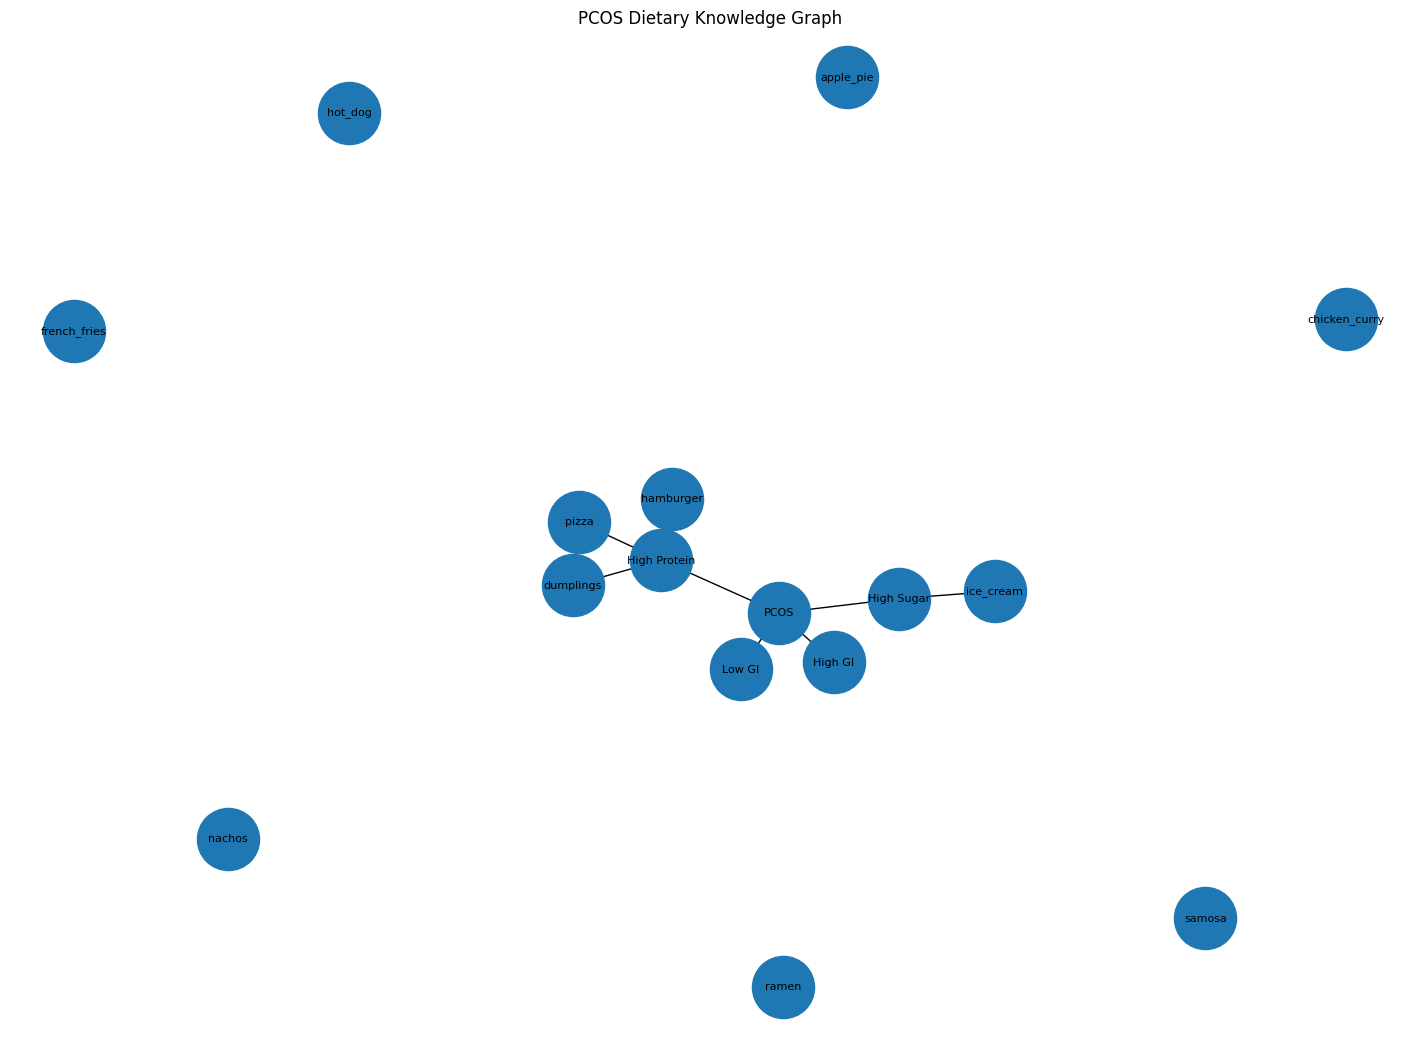

In [133]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=8
)

plt.title(
    "PCOS Dietary Knowledge Graph"
)

plt.show()

In [134]:
def kg_recommend(food_name):

    recommendations = []

    # If food has high sugar
    if (
        food_name,
        'High Sugar'
    ) in G.edges():

        # Recommend protein foods
        for node in G.nodes():

            if (
                node,
                'High Protein'
            ) in G.edges():

                recommendations.append(node)

    return recommendations[:5]

In [135]:
def kg_recommend(food_name):

    recommendations = []

    # If food has high sugar
    if (
        food_name,
        'High Sugar'
    ) in G.edges():

        # Recommend protein foods
        for node in G.nodes():

            if (
                node,
                'High Protein'
            ) in G.edges():

                recommendations.append(node)

    return recommendations[:5]

In [137]:
kg_recommend("apple_pie")

[]

In [139]:
import torch
import networkx as nx

from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv

import torch.nn.functional as F

ModuleNotFoundError: No module named 'torch_geometric'

In [138]:
data = from_networkx(G)

NameError: name 'from_networkx' is not defined

In [74]:
import pandas as pd
# Load data

gi_df        = pd.read_excel("/content/gi_values.xlsx")

# Normalize food names: lowercase, remove underscores/spaces
def normalize_name(s):
    return str(s).strip().lower().replace('_',' ').replace('-', ' ')

gi_df['food']        = gi_df['food'].apply(normalize_name)

# Merge GI: fill missing GI with global mean or default
# First extract numeric GI from strings like "75 ± 2"
gi_df['GI'] = gi_df['gi_values'].str.extract(r'(\d+)').astype(float)
gi_mean = gi_df['GI'].mean()
gi_df['GI'] = gi_df['GI'].fillna(gi_mean)
nutrition_df = nutrition_df.merge(gi_df[['food','GI']], left_on='Food', right_on='food', how='left')
nutrition_df['GI'] = nutrition_df['GI'].fillna(gi_mean)


In [75]:

nutrition_df.head()

,Food,Calories,Protein,Carbohydrates,Sugar,Fiber,Fat,Sodium,Potassium,food,GI
0,apple pie,100,0.10,26.10,13.80,1.0,0.10,47,45,NaN,55.467742
1,baklava,440,6.58,37.55,12.80,2.5,29.34,311,170,NaN,55.467742
2,bibimbap,76,5.50,8.11,1.52,1.1,2.44,435,244,NaN,55.467742
3,bruschetta,171,4.29,21.32,3.34,1.5,7.61,264,187,NaN,55.467742
4,caesar salad,77,4.00,7.49,1.23,1.8,3.41,238,250,NaN,55.467742


In [76]:
import torch
import torch.nn.functional as F
import torch.optim as optim

import pandas as pd
import numpy as np

import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

from torch_geometric.utils import from_networkx
from torch_geometric.nn import SAGEConv

# =========================================================
# 2. NORMALIZE FOOD NAMES
# =========================================================

nutrition_df['Food'] = (

    nutrition_df['Food']

    .str.lower()

    .str.replace('_', ' ')

    .str.strip()

)

# =========================================================
# 3. STANDARDIZE FEATURES
# =========================================================

feature_cols = [
    'Calories',
    'Protein',
    'Carbohydrates',
    'Sugar',
    'Fiber',
    'Fat',
    'Sodium',
    'Potassium'
]

scaler = StandardScaler()

nutrition_df[feature_cols] = scaler.fit_transform(
    nutrition_df[feature_cols]
)


In [77]:
G = nx.Graph()

# ---------------------------------------------------------
# FOOD NODES
# ---------------------------------------------------------

for food in nutrition_df['Food'].unique():

    G.add_node(
        food,
        type='food'
    )

# ---------------------------------------------------------
# NUTRIENT NODES
# ---------------------------------------------------------

nutrients = [
    'Calories',
    'Protein',
    'Carbohydrates',
    'Sugar',
    'Fiber',
    'Fat',
    'Sodium',
    'Potassium'
]

for nutrient in nutrients:

    G.add_node(
        nutrient,
        type='nutrient'
    )

# =========================================================
# 5. ADD FOOD-NUTRIENT EDGES
# =========================================================

for _, row in nutrition_df.iterrows():

    food = row['Food']

    for nutrient in nutrients:

        value = row[nutrient]

        # Create edge if value significant
        if abs(value) > 0.3:

            G.add_edge(
                food,
                nutrient,
                relation='contains_nutrient',
                weight=float(value)
            )

# =========================================================
# 6. ADD PCOS GUIDELINE NODES
# =========================================================

guidelines = [
    'High Protein',
    'High Fiber',
    'Low Sugar',
    'Low Sodium'
]

for g in guidelines:

    G.add_node(
        g,
        type='guideline'
    )

# =========================================================
# 7. ADD GUIDELINE RELATIONS
# =========================================================

for _, row in nutrition_df.iterrows():

    food = row['Food']

    if row['Protein'] > 0.5:

        G.add_edge(
            food,
            'High Protein',
            relation='meets_guideline',
             weight=1.0
        )

    if row['Fiber'] > 0.5:

        G.add_edge(
            food,
            'High Fiber',
            relation='meets_guideline',
             weight=1.0
        )

    if row['Sugar'] > 0.5:

        G.add_edge(
            food,
            'Low Sugar',
            relation='violates_guideline',
             weight=1.0
        )

    if row['Sodium'] > 0.5:

        G.add_edge(
            food,
            'Low Sodium',
            relation='violates_guideline',
             weight=1.0
        )

# =========================================================
# 8. ENCODE NODE TYPES
# =========================================================

node_type_mapping = {
    'food': 0,
    'nutrient': 1,
    'guideline': 2
}

for node in G.nodes():

    G.nodes[node]['type'] = node_type_mapping[
        G.nodes[node]['type']
    ]

# =========================================================
# 9. ENCODE EDGE RELATIONS
# =========================================================

edge_relation_mapping = {
    'contains_nutrient': 0,
    'meets_guideline': 1,
    'violates_guideline': 2
}

for u, v in G.edges():

    G[u][v]['relation'] = edge_relation_mapping[
        G[u][v]['relation']
    ]


In [78]:
data = from_networkx(
    G,
    group_node_attrs=['type'],
    group_edge_attrs=['relation']
)

print(data)

Data(edge_index=[2, 660], weight=[660], x=[59, 1], edge_attr=[660, 1])


In [79]:
num_nodes = data.num_nodes

feat_dim = len(feature_cols)

x = torch.zeros((num_nodes, feat_dim))

for idx, (node, attrs) in enumerate(G.nodes(data=True)):

    t = attrs['type']

    # -----------------------------------------------------
    # FOOD NODE FEATURES
    # -----------------------------------------------------

    if t == 0:

        row = nutrition_df[
            nutrition_df['Food'] == node
        ].iloc[0]

        vec = torch.tensor([

            row['Calories'],
            row['Protein'],
            row['Carbohydrates'],
            row['Sugar'],
            row['Fiber'],
            row['Fat'],
            row['Sodium'],
            row['Potassium']

        ], dtype=torch.float)

        x[idx] = vec

    # -----------------------------------------------------
    # NUTRIENT NODES
    # -----------------------------------------------------

    elif t == 1:

        vec = torch.zeros(feat_dim)

        vec[0] = 1

        x[idx] = vec

    # -----------------------------------------------------
    # GUIDELINE NODES
    # -----------------------------------------------------

    elif t == 2:

        vec = torch.zeros(feat_dim)

        vec[1] = 1

        x[idx] = vec

data.x = x

print(data.x.shape)

torch.Size([59, 8])


In [80]:
model = GNN(
    in_feats=data.x.shape[1],
    hidden_feats=64,
    out_feats=data.x.shape[1]
)

print(model)

# =========================================================
# 14. TRAIN MODEL
# =========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

GNN(
  (conv1): SAGEConv(8, 64, aggr=mean)
  (conv2): SAGEConv(64, 8, aggr=mean)
)


In [81]:
for epoch in range(100):

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    # Graph autoencoder-style loss
    loss = F.mse_loss(
        out,
        data.x
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}, "
            f"Loss={loss.item():.4f}"
        )

Epoch 0, Loss=0.9033
Epoch 10, Loss=0.6927
Epoch 20, Loss=0.5363
Epoch 30, Loss=0.4085
Epoch 40, Loss=0.3029
Epoch 50, Loss=0.2209
Epoch 60, Loss=0.1616
Epoch 70, Loss=0.1206
Epoch 80, Loss=0.0924
Epoch 90, Loss=0.0725


In [82]:
model.eval()

embeddings = model(
    data.x,
    data.edge_index
).detach().numpy()


In [83]:
similarity_matrix = cosine_similarity(
    embeddings
)

nodes = list(G.nodes())


In [84]:

def recommend_food(food_name, top_n=5):

    food_name = (
        food_name
        .lower()
        .replace('_', ' ')
        .strip()
    )

    if food_name not in nodes:

        print(f"{food_name} not found.")

        return None

    idx = nodes.index(food_name)

    scores = similarity_matrix[idx]

    sorted_idx = scores.argsort()[::-1]

    recommendations = []

    for i in sorted_idx:

        candidate = nodes[i]

        if candidate == food_name:
            continue

        # Only food nodes
        if G.nodes[candidate]['type'] == 0:

            recommendations.append({

                'Food': candidate,

                'Similarity':
                    round(scores[i], 2)

            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)


In [85]:
recommend_food("apple_pie")

,Food,Similarity
0,creme brulee,0.96
1,frozen yogurt,0.95
2,bruschetta,0.79
3,ice cream,0.75
4,strawberry shortcake,0.73


In [86]:
def calculate_health_score(row):

    score = 0

    # Positive nutrients
    score += row['Protein'] * 2

    score += row['Fiber'] * 3

    score += row['Potassium'] * 0.01

    # Negative nutrients
    score -= row['Sugar'] * 3

    score -= row['Fat'] * 2

    score -= row['Sodium'] * 0.01

    score -= row['GI'] * 0.5

    return score

In [87]:
nutrition_df['HealthScore'] = (

    nutrition_df.apply(
        calculate_health_score,
        axis=1
    )

)

In [88]:
def classify_food(score):

    if score >= 3:

        return "Healthy"

    elif score >= 0:

        return "Moderate"

    else:

        return "Unhealthy"

In [89]:
nutrition_df['HealthCategory'] = (

    nutrition_df['HealthScore']

    .apply(classify_food)

)

In [90]:
def pcos_suitability(row):

    if (
        row['GI'] < 55
        and row['Sugar'] < 0.5
        and row['Fiber'] > 0
    ):

        return "Highly Recommended"

    elif row['GI'] < 70:

        return "Recommended"

    else:

        return "Avoid"

In [91]:
nutrition_df['PCOS_Suitability'] = (

    nutrition_df.apply(
        pcos_suitability,
        axis=1
    )

)

In [92]:
def recommend_food_v1(food_name, top_n=5):

    food_name = (
        food_name
        .lower()
        .replace('_', ' ')
        .strip()
    )

    if food_name not in nodes:

        print(f"{food_name} not found.")

        return None

    idx = nodes.index(food_name)

    scores = similarity_matrix[idx]

    sorted_idx = scores.argsort()[::-1]

    recommendations = []

    for i in sorted_idx:

        candidate = nodes[i]

        if candidate == food_name:
            continue

        # Only food nodes
        if G.nodes[candidate]['type'] == 0:

            # Get nutrition info
            row = nutrition_df[
                nutrition_df['Food'] == candidate
            ].iloc[0]

            recommendations.append({

                'Food':
                    candidate,

                'Similarity':
                    round(scores[i], 2),

                'HealthScore':
                    round(
                        row['HealthScore'],
                        2
                    ),

                'HealthCategory':
                    row['HealthCategory'],

                'GI':
                    round(row['GI'], 2),

                'PCOS_Suitability':
                    row['PCOS_Suitability']

            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

In [97]:
recommend_food_v1("apple_pie")

,Food,Similarity,HealthScore,HealthCategory,GI,PCOS_Suitability
0,creme brulee,0.96,-35.22,Unhealthy,55.47,Recommended
1,frozen yogurt,0.95,-36.62,Unhealthy,55.47,Recommended
2,bruschetta,0.79,-27.37,Unhealthy,55.47,Recommended
3,ice cream,0.75,-35.36,Unhealthy,51.00,Recommended
4,strawberry shortcake,0.73,-37.23,Unhealthy,55.47,Recommended


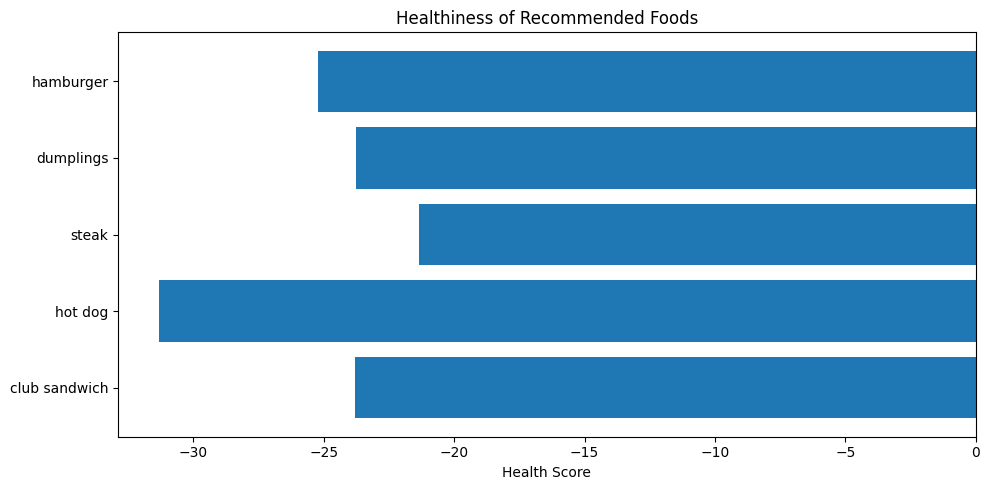

In [101]:
import matplotlib.pyplot as plt
recommendations = recommend_food_v1(
    "pizza"
)

plt.figure(figsize=(10,5))

plt.barh(
    recommendations['Food'],
    recommendations['HealthScore']
)

plt.xlabel("Health Score")

plt.title(
    "Healthiness of Recommended Foods"
)

plt.tight_layout()

plt.show()

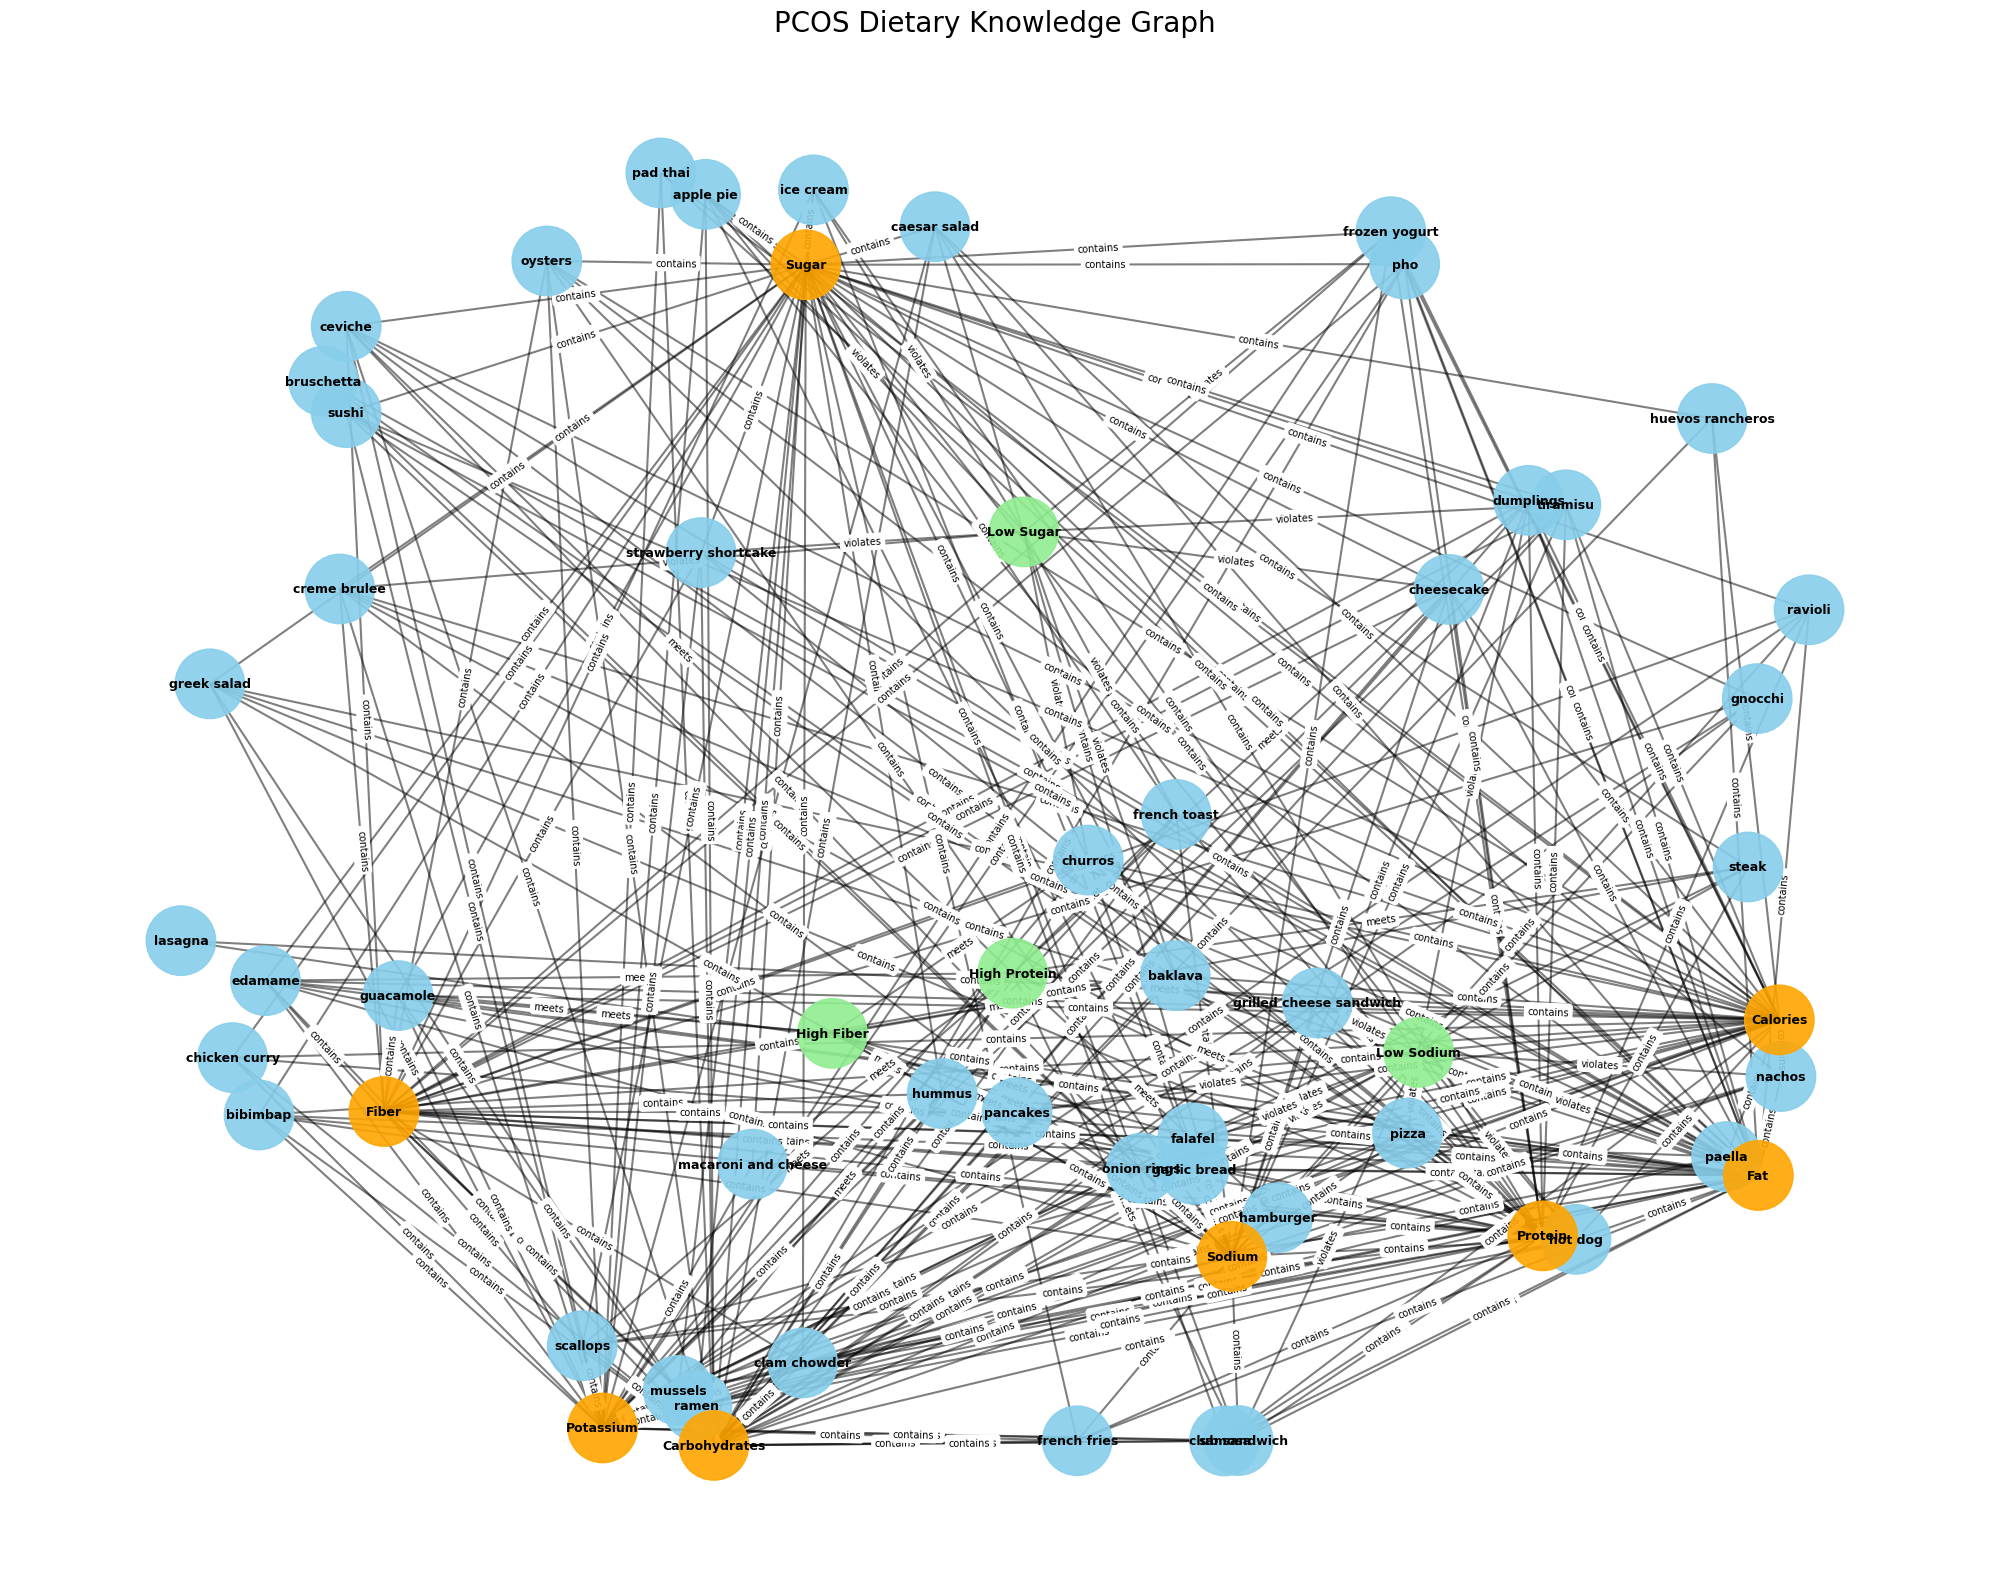

In [102]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(20,16))

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

pos = nx.spring_layout(
    G,
    k=0.5,
    seed=42
)

# ---------------------------------------------------------
# Node Colors
# ---------------------------------------------------------

node_colors = []

for node in G.nodes():

    t = G.nodes[node]['type']

    # Food nodes
    if t == 0:

        node_colors.append('skyblue')

    # Nutrient nodes
    elif t == 1:

        node_colors.append('orange')

    # Guideline nodes
    elif t == 2:

        node_colors.append('lightgreen')

# ---------------------------------------------------------
# Draw Nodes
# ---------------------------------------------------------

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500,
    node_color=node_colors,
    alpha=0.9
)

# ---------------------------------------------------------
# Draw Edges
# ---------------------------------------------------------

nx.draw_networkx_edges(
    G,
    pos,
    width=1.5,
    alpha=0.5
)

# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight='bold'
)

# ---------------------------------------------------------
# Edge Labels
# ---------------------------------------------------------

edge_labels = nx.get_edge_attributes(
    G,
    'relation'
)

# Convert encoded relations back to text
relation_reverse_map = {
    0: 'contains',
    1: 'meets',
    2: 'violates'
}

edge_labels = {

    k: relation_reverse_map[v]

    for k, v in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------

plt.title(
    "PCOS Dietary Knowledge Graph",
    fontsize=20
)

plt.axis('off')

plt.tight_layout()

plt.show()

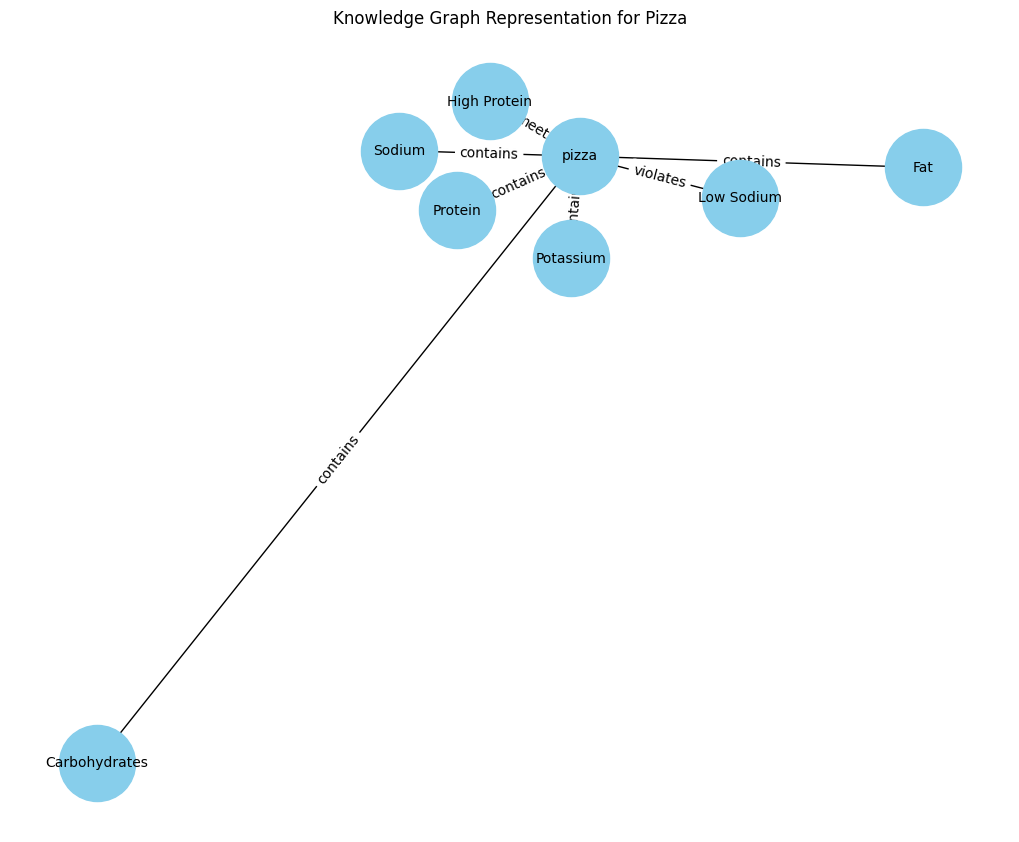

In [103]:
food = "pizza"

neighbors = list(
    G.neighbors(food)
)

sub_nodes = [food] + neighbors

subG = G.subgraph(sub_nodes)

plt.figure(figsize=(10,8))

pos = nx.spring_layout(
    subG,
    seed=42
)

nx.draw(
    subG,
    pos,
    with_labels=True,
    node_size=3000,
    node_color='skyblue',
    font_size=10
)

edge_labels = nx.get_edge_attributes(
    subG,
    'relation'
)

edge_labels = {

    k: relation_reverse_map[v]

    for k, v in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    subG,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "Knowledge Graph Representation for Pizza"
)

plt.axis('off')

plt.show()

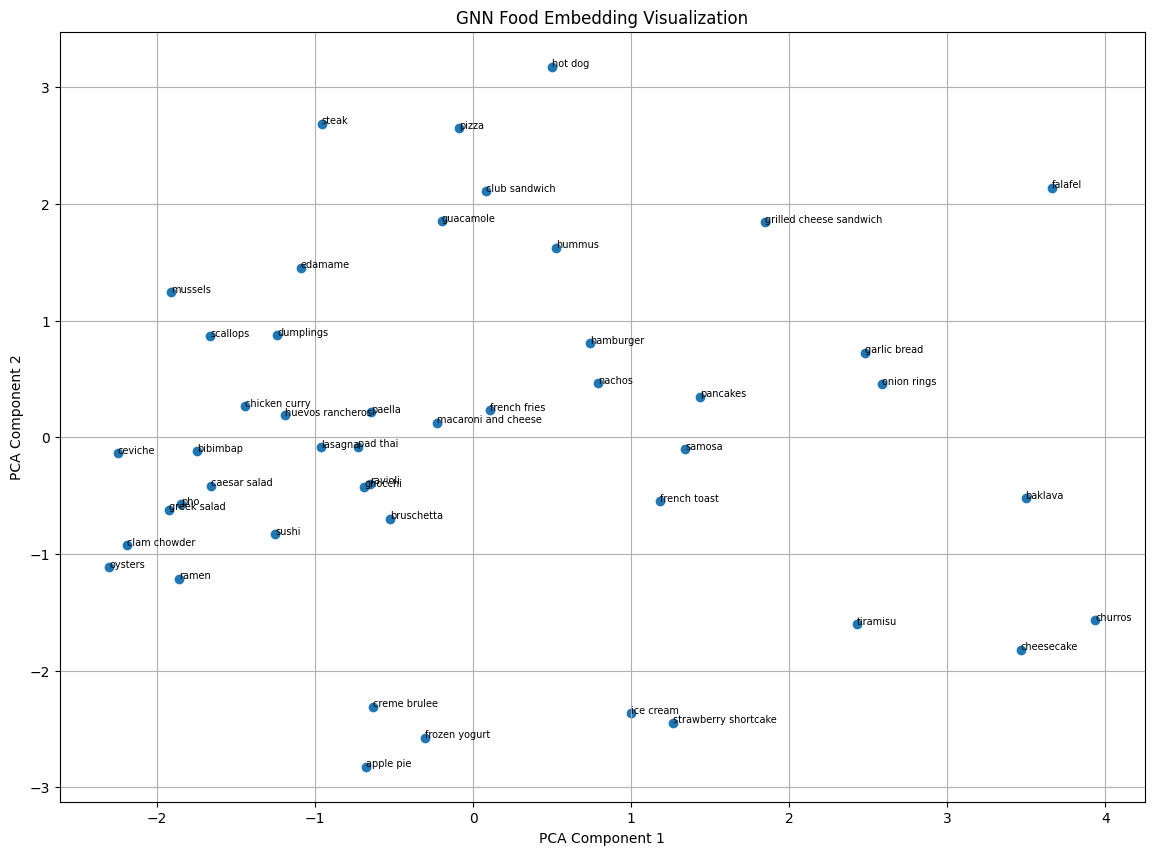

In [106]:
from sklearn.decomposition import PCA

food_nodes = []

food_embeddings = []

for i, node in enumerate(nodes):

    if G.nodes[node]['type'] == 0:

        food_nodes.append(node)

        food_embeddings.append(
            embeddings[i]
        )

food_embeddings = np.array(
    food_embeddings
)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    food_embeddings
)

plt.figure(figsize=(14,10))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

for i, food in enumerate(food_nodes):

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        food,
        fontsize=7
    )

plt.title(
    "GNN Food Embedding Visualization"
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.grid(True)

plt.show()

In [107]:
from sklearn.cluster import KMeans

kmeans = KMeans(

    n_clusters=10,

    random_state=42

)

cluster_labels = kmeans.fit_predict(
    food_embeddings
)

In [108]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(

    food_embeddings,

    cluster_labels

)

print(
    "Silhouette Score:",
    sil_score
)

Silhouette Score: 0.31578016


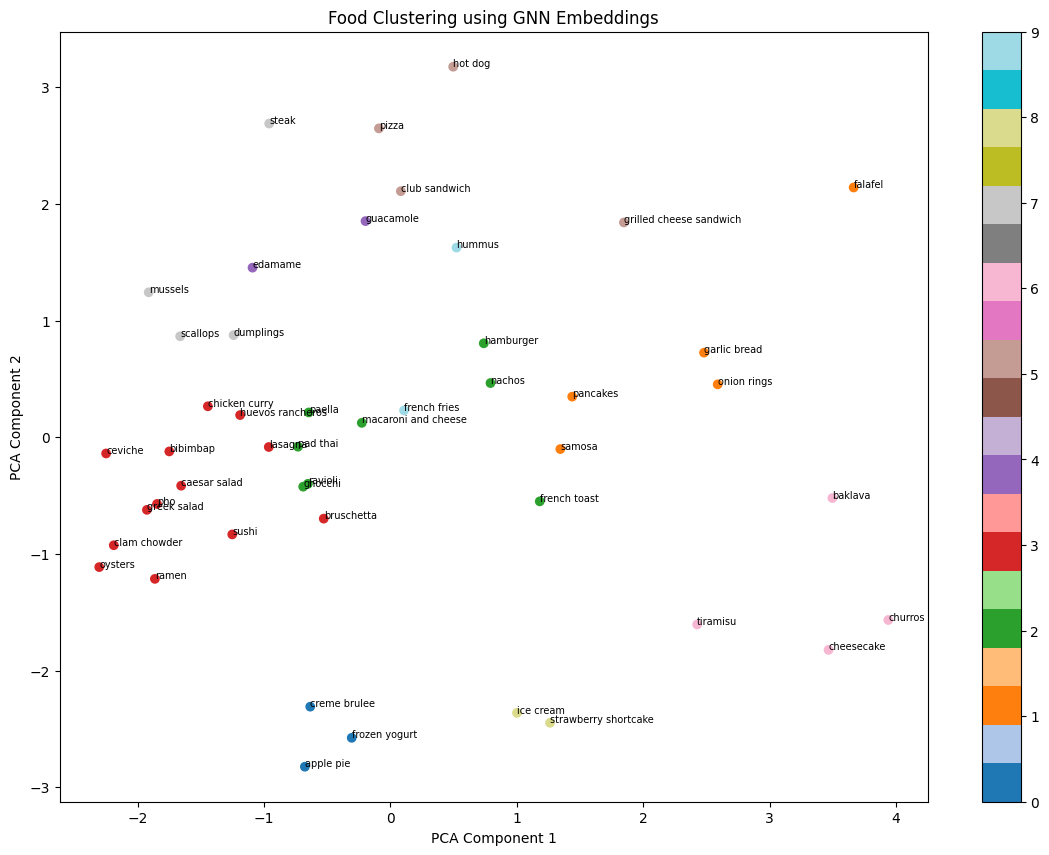

In [109]:
plt.figure(figsize=(14,10))

scatter = plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=cluster_labels,

    cmap='tab20'

)

for i, food in enumerate(food_nodes):

    plt.text(

        X_pca[i,0],

        X_pca[i,1],

        food,

        fontsize=7

    )

plt.title(
    "Food Clustering using GNN Embeddings"
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.colorbar(scatter)

plt.show()

In [110]:
def precision_at_k(

    recommended,

    relevant,

    k=5

):

    recommended_k = recommended[:k]

    relevant_set = set(relevant)

    hits = len(

        set(recommended_k)

        & relevant_set

    )

    return hits / k

In [111]:
recommended = [

    'omelette',

    'miso soup',

    'greek salad',

    'pizza',

    'hamburger'

]

relevant = [

    'omelette',

    'miso soup',

    'greek salad'

]

print(

    "Precision@5:",

    precision_at_k(
        recommended,
        relevant,
        k=5
    )

)

Precision@5: 0.6


In [112]:
def recall_at_k(

    recommended,

    relevant,

    k=5

):

    recommended_k = recommended[:k]

    relevant_set = set(relevant)

    hits = len(

        set(recommended_k)

        & relevant_set

    )

    return hits / len(relevant_set)

In [113]:
recommended = [

    'omelette',

    'miso soup',

    'greek salad',

    'pizza',

    'hamburger'

]

relevant = [

    'omelette',

    'miso soup',

    'greek salad'

]

print(

    "recall@5:",

    recall_at_k(
        recommended,
        relevant,
        k=5
    )

)

recall@5: 1.0


In [114]:
from sklearn.metrics import ndcg_score

true_relevance = [[1,1,1,0,0]]

scores = [[0.95,0.90,0.85,0.50,0.20]]

ndcg = ndcg_score(
    true_relevance,
    scores
)

print("NDCG:", ndcg)

NDCG: 1.0


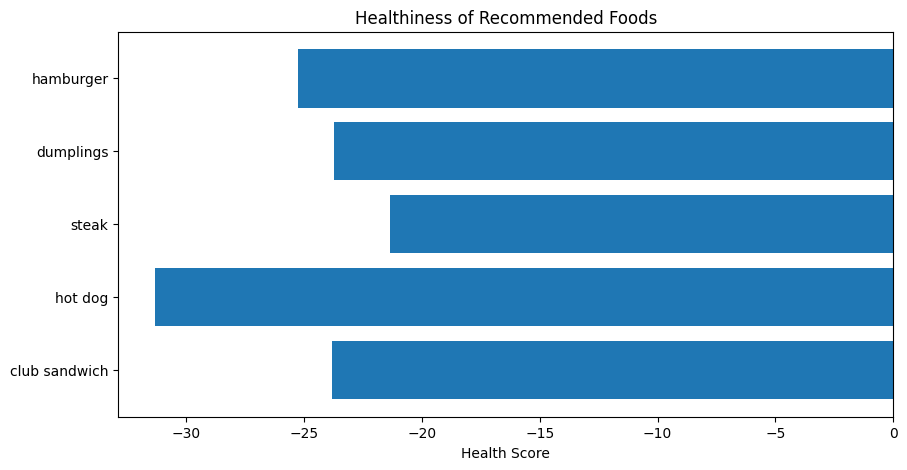

In [116]:
recommendations = recommend_food_v1(
    "pizza"
)

plt.figure(figsize=(10,5))

plt.barh(

    recommendations['Food'],

    recommendations['HealthScore']

)

plt.xlabel(
    "Health Score"
)

plt.title(
    "Healthiness of Recommended Foods"
)

plt.show()

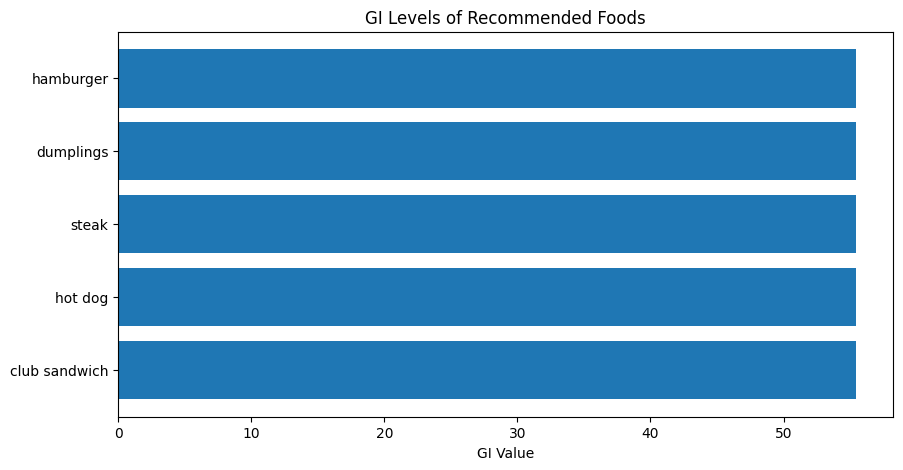

In [117]:
plt.figure(figsize=(10,5))

plt.barh(

    recommendations['Food'],

    recommendations['GI']

)

plt.xlabel("GI Value")

plt.title(
    "GI Levels of Recommended Foods"
)

plt.show()

In [59]:
class GNN(torch.nn.Module):

    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_feats,
            hidden_feats
        )

        self.conv2 = SAGEConv(
            hidden_feats,
            out_feats
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

In [52]:
import networkx as nx

G = nx.Graph()

# Add food nodes
for food in nutrition_df['Food'].unique():
    G.add_node(food, type='food')

# Add nutrient nodes and edges
nutrients = ['Calories','Protein','Carbohydrates','Sugar','Fiber','Fat','Sodium','Potassium']
for nutrient in nutrients:
    G.add_node(nutrient, type='nutrient')
for _, row in nutrition_df.iterrows():
    food = row['Food']
    # Thresholds to create edges (e.g. if > 10g per 100g, else skip)
    if row['Protein (g)'] > 10:
        G.add_edge(food, 'Protein (g)', relation='contains_nutrient')
    if row['Fiber, total dietary (g)'] > 3:
        G.add_edge(food, 'Fiber (g)', relation='contains_nutrient')
    if row['Total Fat (g)'] > 5:
        G.add_edge(food, 'Total Fat (g)', relation='contains_nutrient')
    if row['Sugars, total\n(g)'] > 5:
        G.add_edge(food, 'Sugars, total\n(g)', relation='contains_nutrient')
    if row['Carbohydrate (g)'] > 10:
        G.add_edge(food, 'Carbohydrate (g)', relation='contains_nutrient')
    if row['Sodium (mg)'] > 200:
        G.add_edge(food, 'Sodium (mg)', relation='contains_nutrient')

# Add GI level nodes and edges
G.add_node('High_GI', type='GI_Level')
G.add_node('Medium_GI', type='GI_Level')
G.add_node('Low_GI', type='GI_Level')
for _, row in nutrition_df.iterrows():
    food = row['Food']
    gi = row['GI']
    if gi >= 70:
        G.add_edge(food, 'High_GI', relation='has_GI_level')
    elif gi <= 54:
        G.add_edge(food, 'Low_GI', relation='has_GI_level')
    else:
        G.add_edge(food, 'Medium_GI', relation='has_GI_level')

# Add PCOS guideline nodes
guidelines = ['High_Protein', 'High_Fiber', 'Low_Sugar', 'Low_Sodium']
for g in guidelines:
    G.add_node(g, type='PCOS_Guideline')
# Link foods to guideline nodes based on criteria
for _, row in nutrition_df.iterrows():
    food = row['Food']
    if row['Protein (g)'] > 12:
        G.add_edge(food, 'High_Protein', relation='meets_guideline')
    if row['Fiber, total dietary (g)'] > 5:
        G.add_edge(food, 'High_Fiber', relation='meets_guideline')
    if row['Sugars, total\n(g)'] > 10:
        G.add_edge(food, 'Low_Sugar', relation='violates_guideline')
    if row['Sodium (mg)'] > 300:
        G.add_edge(food, 'Low_Sodium', relation='violates_guideline')


KeyError: 'Protein (g)'

In [13]:
! pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.2 MB/s eta 0:00:00


In [16]:
# -----------------------------------
# Encode node types
# -----------------------------------

node_type_mapping = {
    'food': 0,
    'nutrient': 1,
    'GI_Level': 2,
    'PCOS_Guideline': 3
}

for node in G.nodes():
    G.nodes[node]['type'] = node_type_mapping[G.nodes[node]['type']]

# -----------------------------------
# Encode edge relations
# -----------------------------------

edge_relation_mapping = {
    'contains_nutrient': 0,
    'has_GI_level': 1,
    'meets_guideline': 2,
    'violates_guideline': 3
}

for u, v in G.edges():
    G[u][v]['relation'] = edge_relation_mapping[G[u][v]['relation']]

In [17]:
from torch_geometric.utils import from_networkx

data = from_networkx(
    G,
    group_node_attrs=['type'],
    group_edge_attrs=['relation']
)

print(data)

Data(edge_index=[2, 50044], x=[5444, 1], edge_attr=[50044, 1])


In [18]:
nutrient_columns = {
    'Protein (g)': 'Protein (g)',
    'Fiber (g)': 'Fiber, total dietary (g)',
    'Total Fat (g)': 'Total Fat (g)',
    'Sugars (g)': 'Sugars, total\n(g)',
    'Sodium (mg)': 'Sodium (mg)',
    'Carbohydrate (g)': 'Carbohydrate (g)'
}

In [20]:
import torch

num_nodes = data.num_nodes

feat_dim = 8

x = torch.zeros((num_nodes, feat_dim))

# -----------------------------------
# Create node features
# -----------------------------------

for idx, (node, attrs) in enumerate(G.nodes(data=True)):

    t = attrs['type']

    # -----------------------------------
    # FOOD NODES
    # -----------------------------------

    if t == 0:   # food

        row = nutrition_df[
            nutrition_df['Food'] == node
        ].iloc[0]

        vec = torch.tensor([

            row['Energy (kcal)'],

            row['Carbohydrate (g)'],

            row['Sugars, total\n(g)'],

            row['Fiber, total dietary (g)'],

            row['Total Fat (g)'],

            row['Sodium (mg)'],

            row['Protein (g)'],

            row['GI']

        ], dtype=torch.float)

        x[idx] = vec

    # -----------------------------------
    # NUTRIENT NODES
    # -----------------------------------

    elif t == 1:   # nutrient

        vec = torch.zeros(feat_dim)

        vec[0] = 1

        x[idx] = vec

    # -----------------------------------
    # GI LEVEL NODES
    # -----------------------------------

    elif t == 2:   # GI_Level

        vec = torch.zeros(feat_dim)

        vec[1] = 1

        x[idx] = vec

    # -----------------------------------
    # PCOS GUIDELINE NODES
    # -----------------------------------

    elif t == 3:   # PCOS_Guideline

        vec = torch.zeros(feat_dim)

        vec[2] = 1

        x[idx] = vec

# -----------------------------------
# Assign features
# -----------------------------------

data.x = x

print(data.x.shape)

torch.Size([5444, 8])


In [22]:
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

# -----------------------------------
# Graph Neural Network
# -----------------------------------

class GNN(torch.nn.Module):

    def __init__(
        self,
        in_feats,
        hidden_feats,
        out_feats
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_feats,
            hidden_feats
        )

        self.conv2 = SAGEConv(
            hidden_feats,
            out_feats
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return x

# -----------------------------------
# Create model
# -----------------------------------

model = GNN(
    in_feats=data.x.shape[1],
    hidden_feats=64,
    out_feats=32
)

print(model)

GNN(
  (conv1): SAGEConv(8, 64, aggr=mean)
  (conv2): SAGEConv(64, 32, aggr=mean)
)


In [24]:
model = GNN(
    in_feats=data.x.shape[1],
    hidden_feats=64,
    out_feats=data.x.shape[1]
)

print(model)


GNN(
  (conv1): SAGEConv(8, 64, aggr=mean)
  (conv2): SAGEConv(64, 8, aggr=mean)
)


In [25]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

for epoch in range(100):

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    loss = F.mse_loss(
        out,
        data.x
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch}, "
            f"Loss={loss.item():.4f}"
        )

Epoch 0, Loss=37264.1641
Epoch 10, Loss=25967.8652
Epoch 20, Loss=18704.3301
Epoch 30, Loss=13995.8574
Epoch 40, Loss=10768.2119
Epoch 50, Loss=8610.1680
Epoch 60, Loss=7197.5718
Epoch 70, Loss=6185.1079
Epoch 80, Loss=5324.0347
Epoch 90, Loss=4510.4741


In [26]:
model.eval()

embeddings = model(
    data.x,
    data.edge_index
).detach()


In [28]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(
    embeddings
)

nodes = list(G.nodes())


In [33]:
valid_foods = [

    'apple pie',
    'cannoli',
    'chicken curry',
    'chocolate cake',
    'cup cakes',
    'donuts',
    'dumplings',
    'french fries',
    'fried rice',
    'hamburger',
    'hot and sour soup',
    'hot dog',
    'ice cream',
    'nachos',
    'omelette',
    'pizza',
    'ramen',
    'samosa',
    'spring rolls',
    'waffles'
]

In [34]:
def recommend_food(food_name, top_n=5):

    # -----------------------------------
    # Normalize input
    # -----------------------------------

    food_name = (
        food_name
        .lower()
        .replace('_', ' ')
        .strip()
    )

    if food_name not in nodes:

        print(f"{food_name} not found.")

        return None

    idx = nodes.index(food_name)

    scores = similarity_matrix[idx]

    sorted_idx = scores.argsort()[::-1]

    recommendations = []

    for i in sorted_idx:

        candidate = nodes[i]

        # Skip same food
        if candidate == food_name:
            continue

        # -----------------------------------
        # ONLY recommend selected foods
        # -----------------------------------

        if candidate in valid_foods:

            recommendations.append({

                'Food': candidate,

                'Similarity':
                    round(scores[i], 2)

            })

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(recommendations)

In [35]:
print(nodes[:20])

['milk, nfs', 'milk, whole', 'milk, reduced fat (2%)', 'milk, low fat (1%)', 'milk, fat free (skim)', 'milk, lactose free, low fat (1%)', 'milk, lactose free, fat free (skim)', 'milk, lactose free, reduced fat (2%)', 'milk, lactose free, whole', 'buttermilk', 'kefir', 'goat milk', 'milk, dry, reconstituted, nonfat', 'milk, dry, reconstituted, whole', 'milk, evaporated, ns as to fat content', 'milk, evaporated, whole', 'milk, evaporated, reduced fat (2%)', 'milk, evaporated, fat free (skim)', 'milk, condensed, sweetened', 'non dairy milk, nfs']


In [41]:
recommend_food("hot and sour soup")

hot and sour soup not found.
